# EasyVisa - Visa Approval Prediction

## Problem Statment
The OFLC Process hundreds of thousands of visa applications annually. With volume growing 9% YoY, manual review is no longer scalable. EasyVisa has been engaged to build a Machine Learning solution that:
1. Predicts the likelihood of visa certification or denial
2. Identifies the key drivers that influence case status
3. Recommends suitable applicant profile for certification
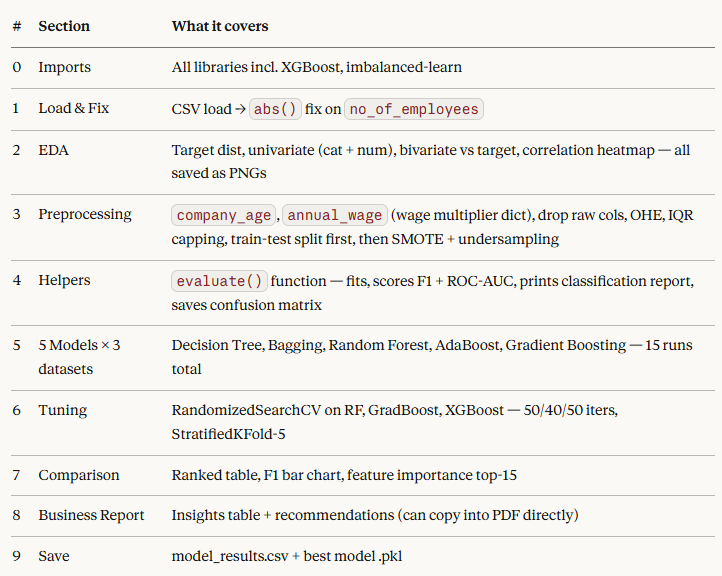

In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay )

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import (BaggingRegressor, RandomForestRegressor, GradientBoostingClassifier,AdaBoostClassifier)

from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc


from xgboost import XGBClassifier




In [56]:
df=pd.read_csv(r"D:\DSGA\6 Robust Data Modeling with Ensembling and Tuning Techniques\Project\EasyVisa.csv")
df.head(10)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.1400,Year,Y,Certified
6,EZYV07,Asia,Bachelor's,N,N,4985,1994,South,53635.3900,Year,Y,Certified
7,EZYV08,North America,Bachelor's,Y,N,3035,1924,West,418.2298,Hour,Y,Denied
8,EZYV09,Asia,Bachelor's,N,N,4810,2012,Midwest,74362.1900,Year,Y,Certified
9,EZYV10,Europe,Doctorate,Y,N,2251,1995,South,67514.7600,Year,Y,Certified


In [57]:
df.shape

(25480, 12)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [59]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [60]:
# Normalize wages to annual
def to_annual(row):
    w = row['prevailing_wage']
    u = row['unit_of_wage']
    if u=='Hour': return w * 2080 # Considering 40 working hours per week
    if u=='Week':return w * 52
    elif u=='Month': return w * 12
    return w
df['annual_wage']=df.apply(to_annual,axis=1)


In [61]:
df.head(10)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,annual_wage
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,1231782.032
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,83425.650
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,122996.860
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,83434.030
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,149907.390
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.1400,Year,Y,Certified,78252.140
6,EZYV07,Asia,Bachelor's,N,N,4985,1994,South,53635.3900,Year,Y,Certified,53635.390
7,EZYV08,North America,Bachelor's,Y,N,3035,1924,West,418.2298,Hour,Y,Denied,869917.984
8,EZYV09,Asia,Bachelor's,N,N,4810,2012,Midwest,74362.1900,Year,Y,Certified,74362.190
9,EZYV10,Europe,Doctorate,Y,N,2251,1995,South,67514.7600,Year,Y,Certified,67514.760


In [62]:
cat_cols= df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"\nColumn:{col}")
    print(df[col].value_counts(dropna=False))


Column:case_id
case_id
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
EZYV05       1
            ..
EZYV25476    1
EZYV25477    1
EZYV25478    1
EZYV25479    1
EZYV25480    1
Name: count, Length: 25480, dtype: int64

Column:continent
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

Column:education_of_employee
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

Column:has_job_experience
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64

Column:requires_job_training
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64

Column:region_of_employment
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64

Column:unit_of_wage
unit_of_wage
Year     22962
Hour   

In [63]:
num_cols=df.select_dtypes(include='number').columns.tolist()
print(df[num_cols].describe().T.round(2))

                   count       mean        std      min       25%       50%  \
no_of_employees  25480.0    5667.04   22877.93   -26.00   1022.00   2109.00   
yr_of_estab      25480.0    1979.41      42.37  1800.00   1976.00   1997.00   
prevailing_wage  25480.0   74455.81   52815.94     2.14  34015.48  70308.21   
annual_wage      25480.0  197391.16  578591.67   100.00  47107.96  82839.46   

                       75%          max  
no_of_employees    3504.00    602069.00  
yr_of_estab        2005.00      2016.00  
prevailing_wage  107735.51    319210.27  
annual_wage      124825.04  14569149.40  


In [64]:
#SanityCheck
print("\n---Sanity Checks---")
print(f"yr_of_estab:min={df['yr_of_estab'].min()}, max={df['yr_of_estab'].max()}")
print(f"annual_wage : min={df['annual_wage'].min()}, max={df['annual_wage'].max()}")
print(f"no_of_employees : min={df['no_of_employees'].min()}, max={df["no_of_employees"].max()}")
print(f"negative number of employees: {(df['no_of_employees']<0).sum()}")


---Sanity Checks---
yr_of_estab:min=1800, max=2016
annual_wage : min=100.0, max=14569149.4
no_of_employees : min=-26, max=602069
negative number of employees: 33


In [65]:
print(df[df['no_of_employees']<0])

         case_id      continent education_of_employee has_job_experience  \
245      EZYV246         Europe              Master's                  N   
378      EZYV379           Asia            Bachelor's                  N   
832      EZYV833  South America              Master's                  Y   
2918    EZYV2919           Asia              Master's                  Y   
6439    EZYV6440           Asia            Bachelor's                  N   
6634    EZYV6635           Asia            Bachelor's                  Y   
7224    EZYV7225         Europe             Doctorate                  N   
7281    EZYV7282           Asia           High School                  N   
7318    EZYV7319           Asia            Bachelor's                  Y   
7761    EZYV7762           Asia              Master's                  N   
9872    EZYV9873         Europe              Master's                  Y   
11493  EZYV11494           Asia           High School                  Y   
13471  EZYV1

In [66]:
#Convert negative to positive
df['no_of_employees'] = df['no_of_employees'].abs()

In [67]:
print(df[df['no_of_employees']<0])

Empty DataFrame
Columns: [case_id, continent, education_of_employee, has_job_experience, requires_job_training, no_of_employees, yr_of_estab, region_of_employment, prevailing_wage, unit_of_wage, full_time_position, case_status, annual_wage]
Index: []


In [68]:
print(f"no_of_employees : min={df['no_of_employees'].min()}, max={df["no_of_employees"].max()}")

no_of_employees : min=11, max=602069


In [69]:
print(df[df['yr_of_estab'] < 1900]['yr_of_estab'].value_counts().sort_index())

yr_of_estab
1800    16
1801    12
1804    18
1807     6
1809     9
        ..
1895    22
1896    31
1897    37
1898    33
1899    32
Name: count, Length: 82, dtype: int64


In [70]:
print(df[df['yr_of_estab']<1900][['case_id','yr_of_estab','no_of_employees','case_status']].sort_values('yr_of_estab'))

         case_id  yr_of_estab  no_of_employees case_status
7399    EZYV7400         1800            23824      Denied
13155  EZYV13156         1800              573   Certified
1472    EZYV1473         1800             1561   Certified
6083    EZYV6084         1800             1604   Certified
12102  EZYV12103         1800              808      Denied
...          ...          ...              ...         ...
20032  EZYV20033         1899             2989   Certified
18759  EZYV18760         1899              547   Certified
18982  EZYV18983         1899             1630      Denied
2535    EZYV2536         1899             4647   Certified
22049  EZYV22050         1899              786   Certified

[2108 rows x 4 columns]


In [71]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.089207,22877.917453,11.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
df.drop(columns=['prevailing_wage','unit_of_wage'],inplace=True)

In [73]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,full_time_position,case_status,annual_wage
0,EZYV01,Asia,High School,N,N,14513,2007,West,Y,Denied,1231782.032
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,Y,Certified,83425.650
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,Y,Denied,122996.860
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,Y,Denied,83434.030
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,Y,Certified,149907.390


In [74]:
#Replacing Yes with number 1 and No with number 0
df['has_job_experience'] = (df['has_job_experience']=='Y').astype(int)
df['requires_job_training'] = (df['requires_job_training'] =='Y').astype(int)
df['full_time_position'] = (df['full_time_position'] =='Y').astype(int)

In [75]:
df.head()


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,full_time_position,case_status,annual_wage
0,EZYV01,Asia,High School,0,0,14513,2007,West,1,Denied,1231782.032
1,EZYV02,Asia,Master's,1,0,2412,2002,Northeast,1,Certified,83425.650
2,EZYV03,Asia,Bachelor's,0,1,44444,2008,West,1,Denied,122996.860
3,EZYV04,Asia,Bachelor's,0,0,98,1897,West,1,Denied,83434.030
4,EZYV05,Africa,Master's,1,0,1082,2005,South,1,Certified,149907.390


In [77]:
df['has_job_experience'].value_counts()

has_job_experience
1    14802
0    10678
Name: count, dtype: int64

In [79]:
print(df['case_status'].value_counts())
print(df['case_status'].value_counts(normalize=True).round(3))

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64
case_status
Certified    0.668
Denied       0.332
Name: proportion, dtype: float64


In [83]:
print(df['no_of_employees'].describe())


count     25480.000000
mean       5667.089207
std       22877.917453
min          11.000000
25%        1022.000000
50%        2109.000000
75%        3504.000000
max      602069.000000
Name: no_of_employees, dtype: float64


In [95]:
#Companies where no of employees are more than 100,000
print((df['no_of_employees'] > 100_000).sum())

271


## 2. Exploratory Data Analysis

####  2.1 PROBLEM DEFINITION
##### The Office of Foreign Labor Certification (OFLC) processes thousands of visa
##### applications yearly. With volume growing 9% YoY, manual review is unsustainable.
##### EasyVisa has been hired to build a classification model that:
* 1. Predicts visa approval (Certified/Denied) based on applicant profile
* 2. Identifies key drivers that influence case status
#####  Dataset: 25,480 cases | 12 features | Target: case_status (66.8% Certified)

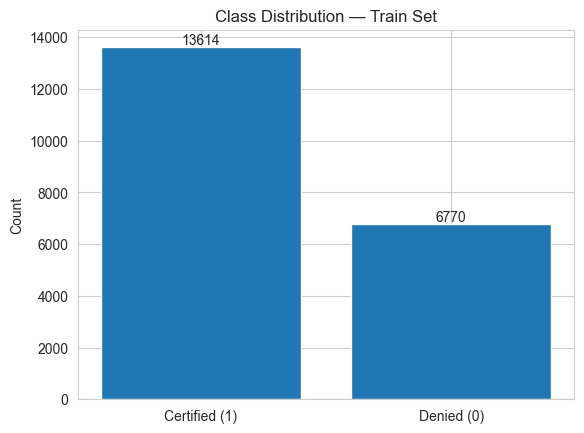

In [269]:
labels = ['Certified (1)', 'Denied (0)']
values = [13614, 6770]

plt.bar(labels, values)
plt.title('Class Distribution — Train Set')
plt.ylabel('Count')
for i, v in enumerate(values):
    plt.text(i, v + 100, str(v), ha='center')
plt.show()

### 2.2 Univariate Analysis

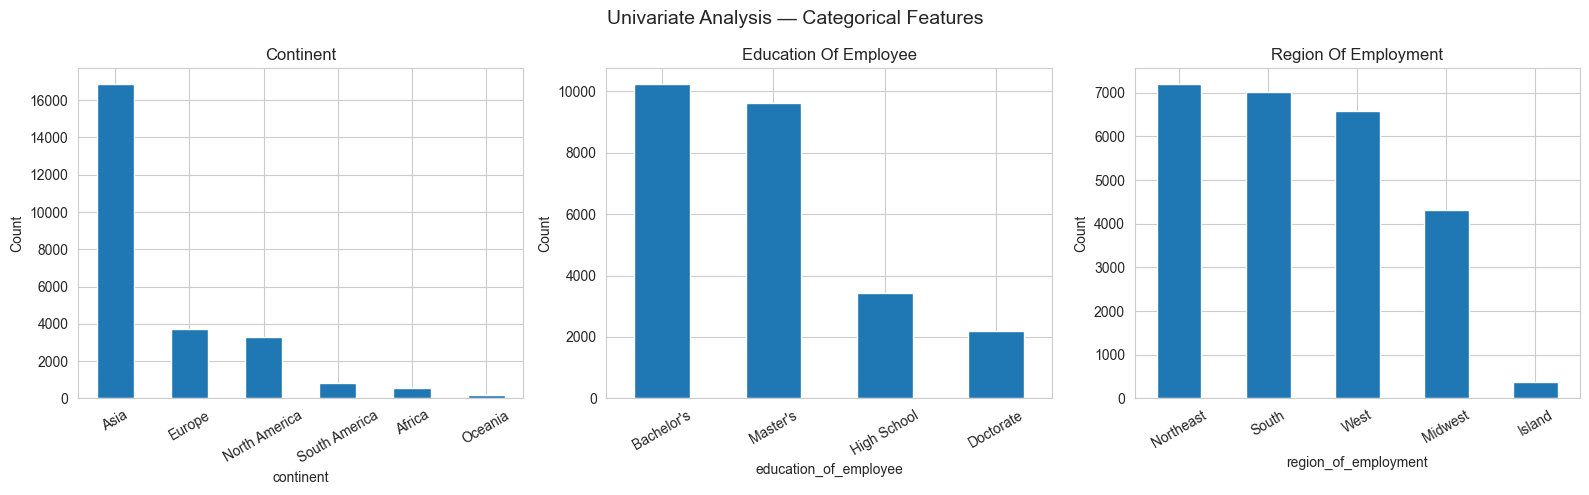

In [106]:
# Categorical columns
cat_cols = ['continent', 'education_of_employee', 'region_of_employment']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()


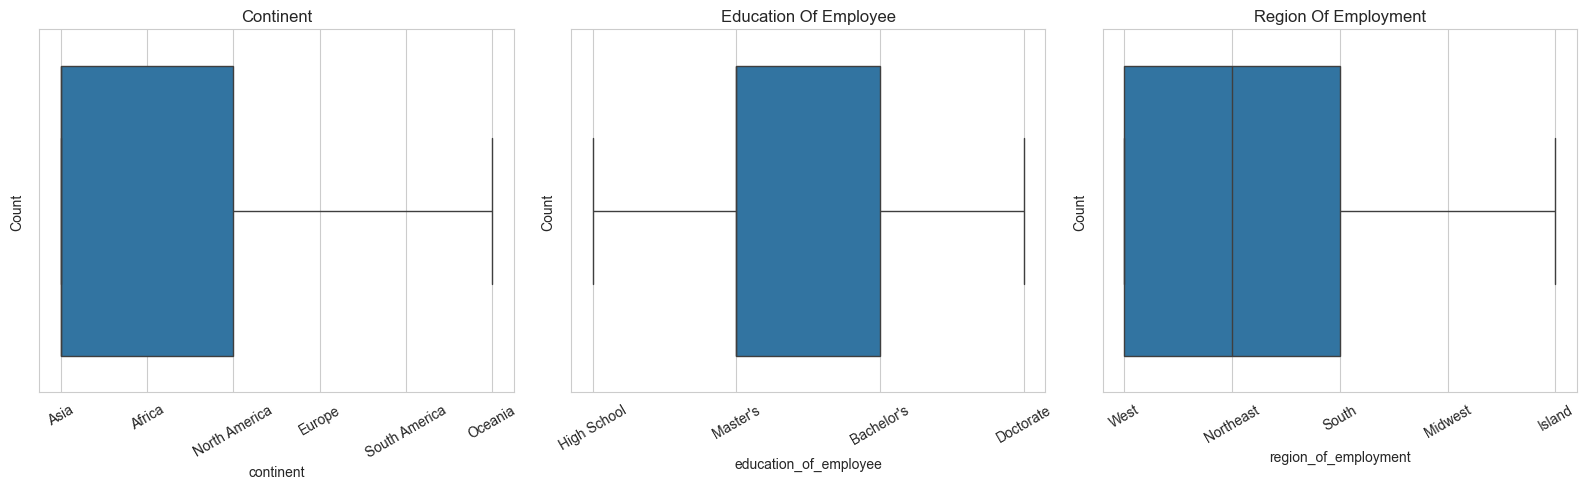

In [168]:
cat_cols = ['continent', 'education_of_employee', 'region_of_employment']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


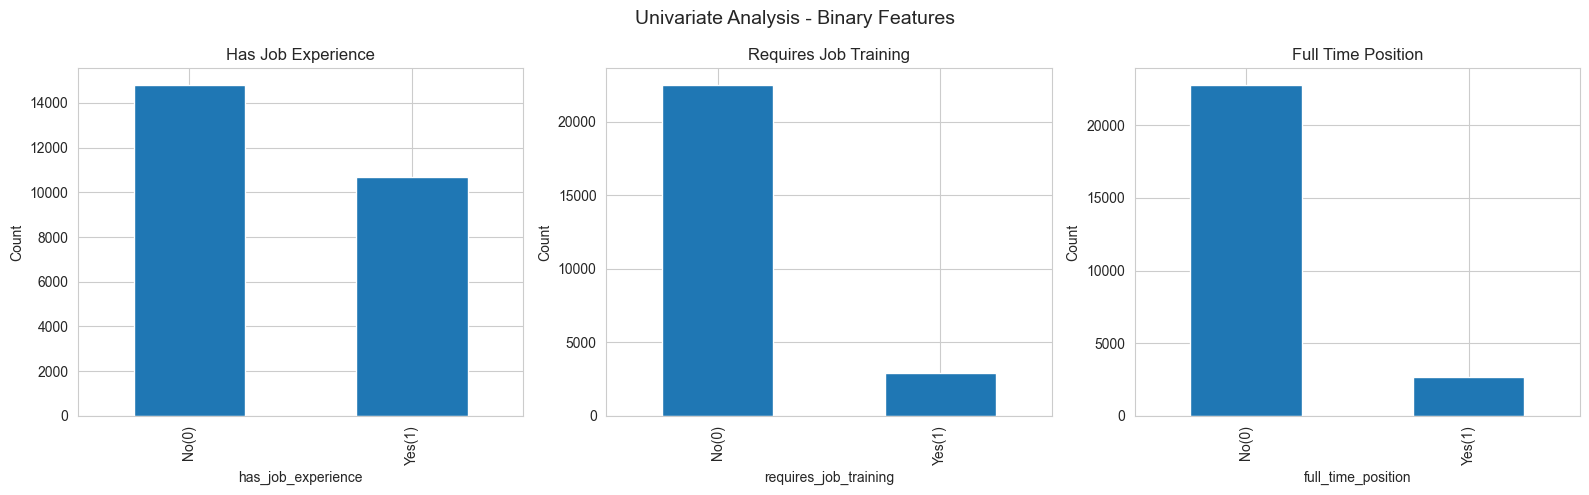

In [164]:
#Binary columns
binary_cols=['has_job_experience','requires_job_training','full_time_position']

fig,axes=plt.subplots(1,3,figsize=(16,5))

for i,col in enumerate(binary_cols):
    df[col].value_counts().plot(kind='bar',ax=axes[i])
    axes[i].set_title(col.replace('_',' ').title())
    axes[i].set_xticklabels(['No(0)','Yes(1)'])
    axes[i].set_ylabel('Count')

plt.suptitle('Univariate Analysis - Binary Features', fontsize=14)
plt.tight_layout()
plt.show()

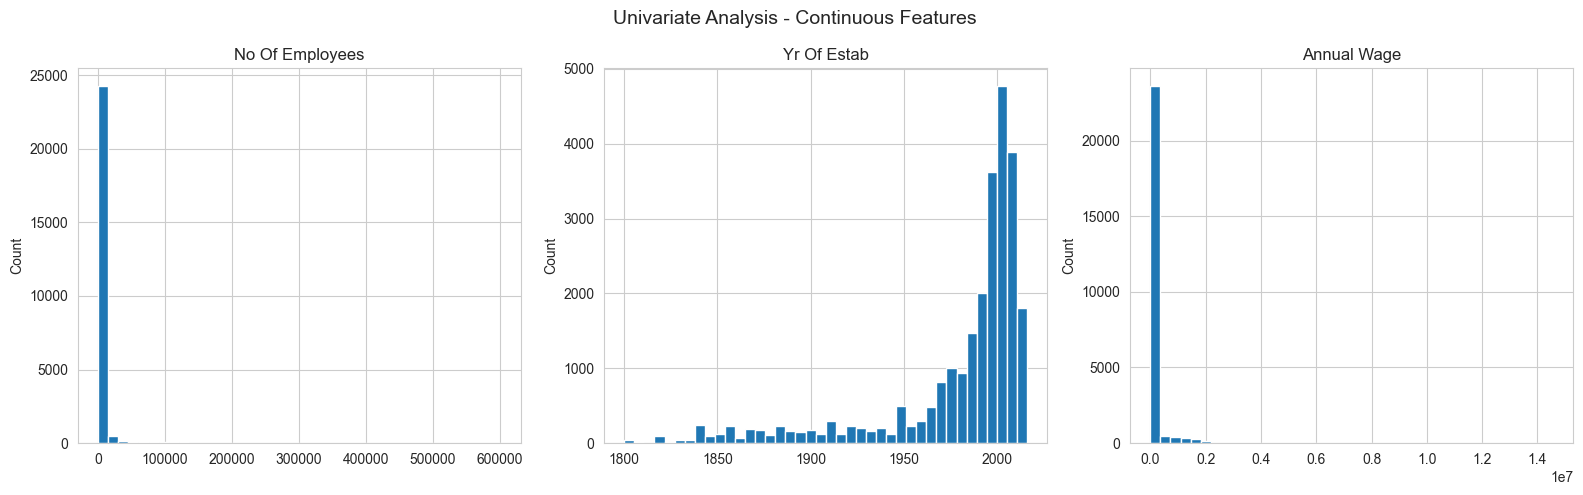

In [119]:
# Continuous
num_cols=['no_of_employees','yr_of_estab','annual_wage']

fig,axes=plt.subplots(1,3,figsize=(16,5))

for i,col in enumerate(num_cols):
    axes[i].hist(df[col],bins=40)
    axes[i].set_title(col.replace('_',' ').title())
    axes[i].set_ylabel('Count')

plt.suptitle('Univariate Analysis - Continuous Features', fontsize=14)
plt.tight_layout()
plt.show()

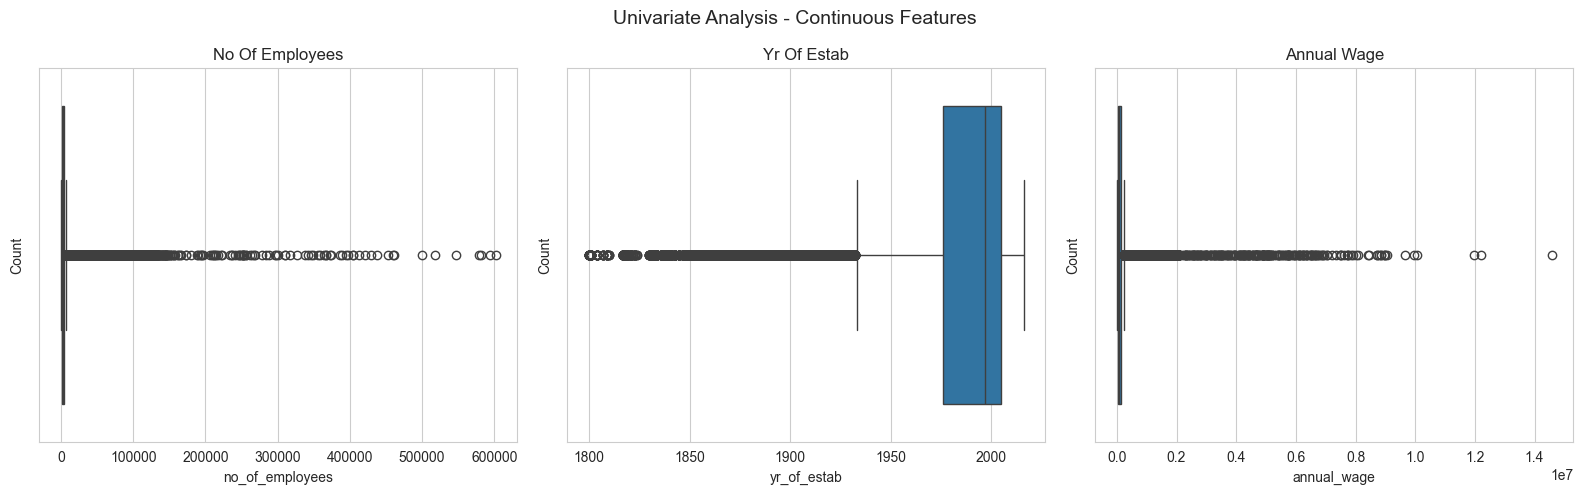

In [167]:
num_cols=['no_of_employees','yr_of_estab','annual_wage']

fig,axes=plt.subplots(1,3,figsize=(16,5))

for i,col in enumerate(num_cols):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col.replace('_',' ').title())
    axes[i].set_ylabel('Count')

plt.suptitle('Univariate Analysis - Continuous Features', fontsize=14)
plt.tight_layout()
plt.show()

In [181]:
def histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2, sharex=True, gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(data=df, x=feature, ax=ax_box2, showmeans=True, color="violet")

    if bins:
        sns.histplot(data=df, x=feature, kde=kde, ax=ax_hist2, bins=bins)
    else:
        sns.histplot(data=df, x=feature, kde=kde, ax=ax_hist2)

    ax_hist2.axvline(df[feature].mean(), color="green", linestyle="--", label="Mean")
    ax_hist2.axvline(df[feature].median(), color="black", linestyle="-", label="Median")
    ax_hist2.legend()

    ax_box2.set_title(f'Distribution of {feature}', fontsize=14)
    plt.tight_layout()
    plt.show()

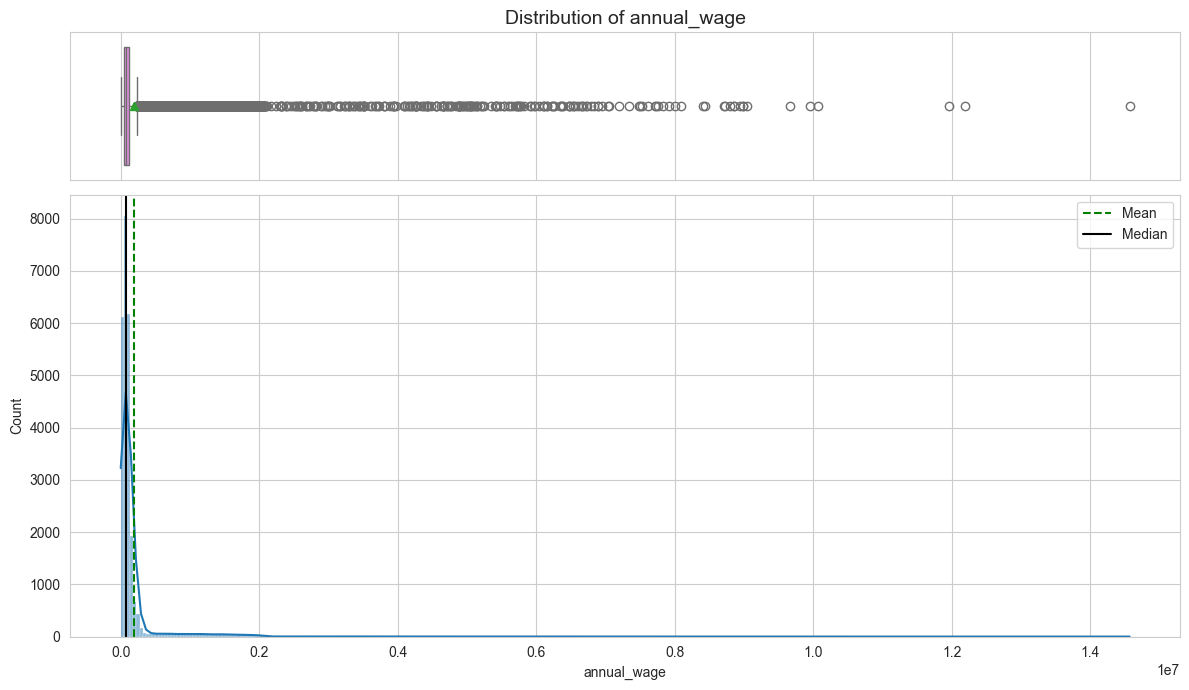

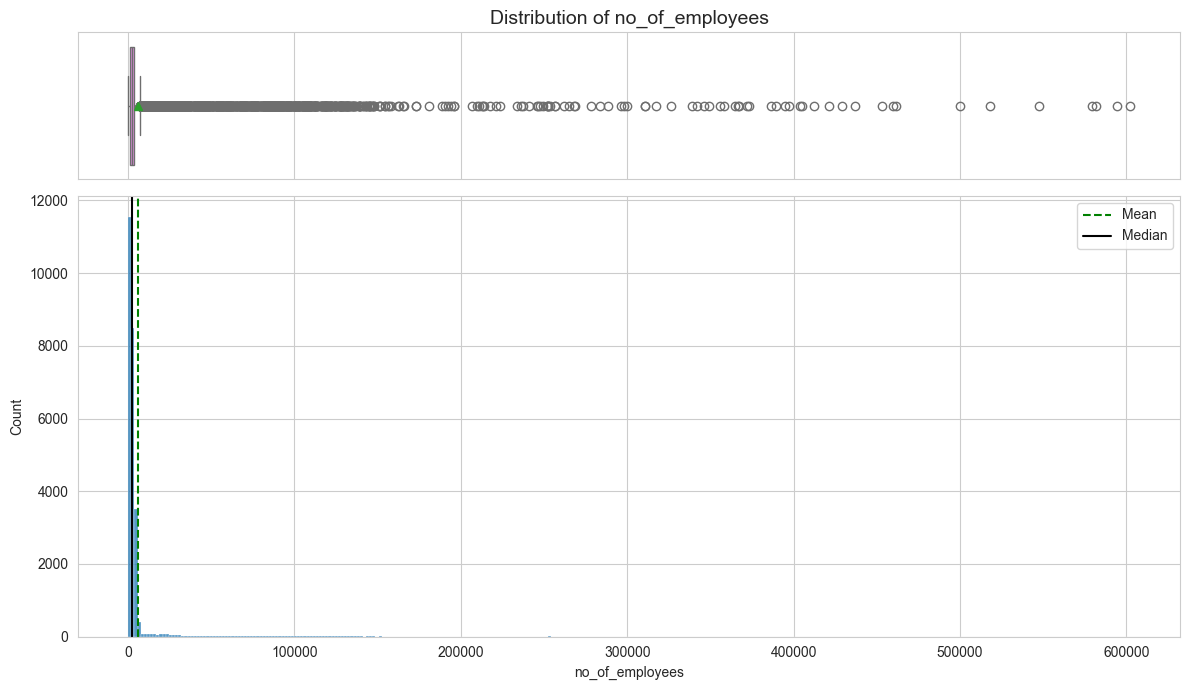

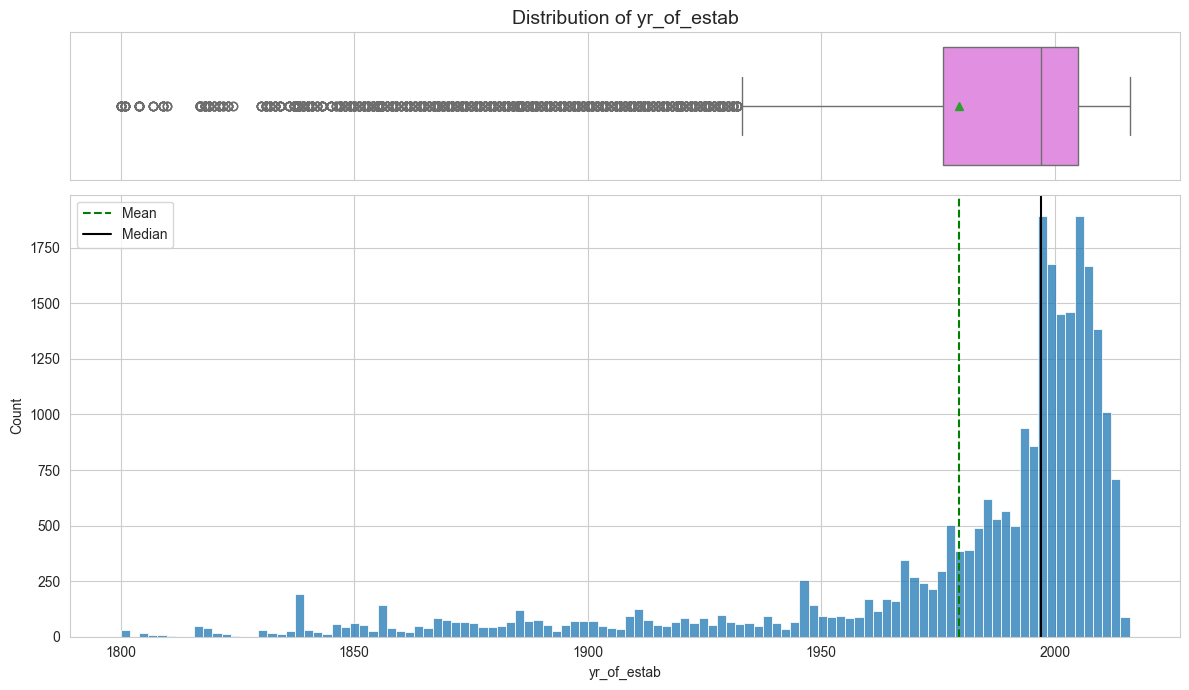

In [182]:
histogram_boxplot(df, 'annual_wage', kde=True)
histogram_boxplot(df, 'no_of_employees')
histogram_boxplot(df, 'yr_of_estab')

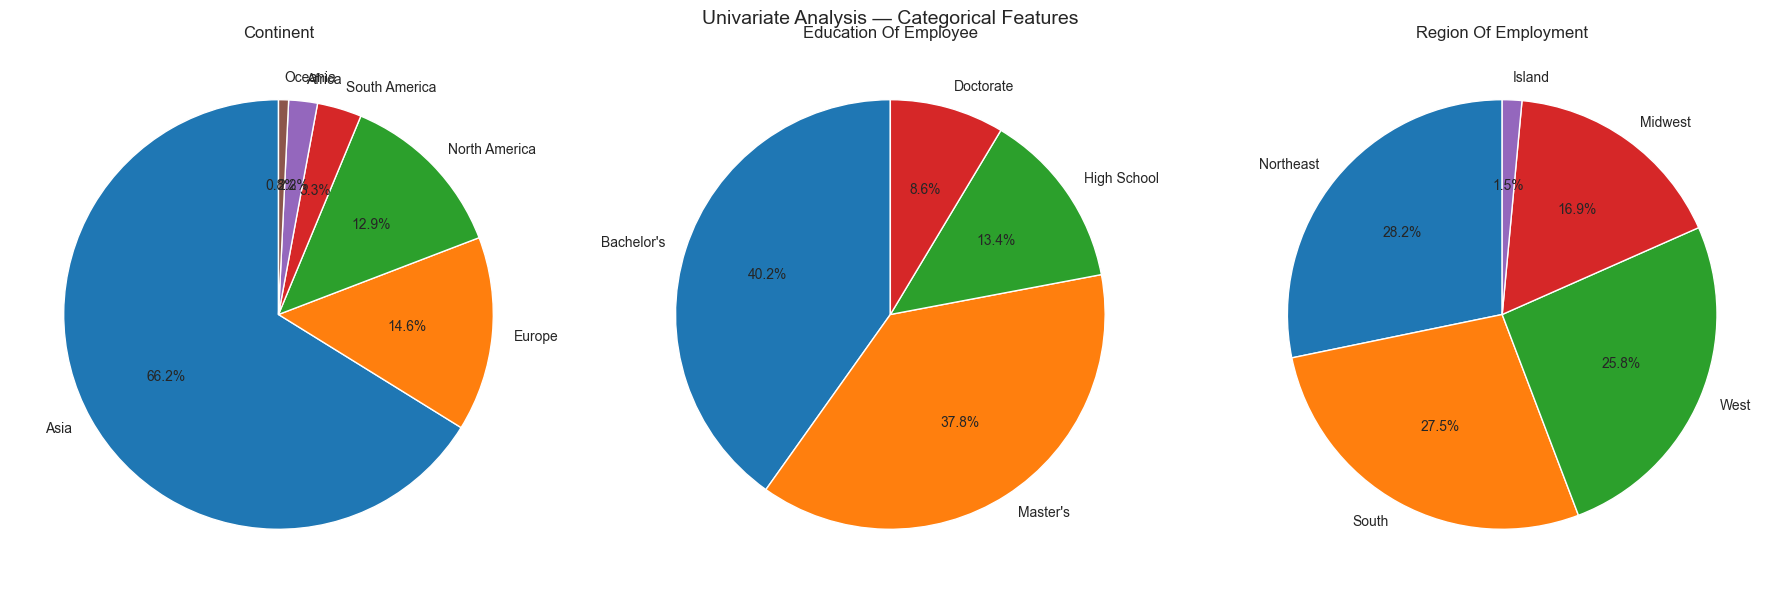

In [183]:
# Pie charts
cat_cols = ['continent', 'education_of_employee', 'region_of_employment']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(col.replace('_', ' ').title())

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=14)
plt.tight_layout()
plt.show()

### 2.3 Bivariate Analysis


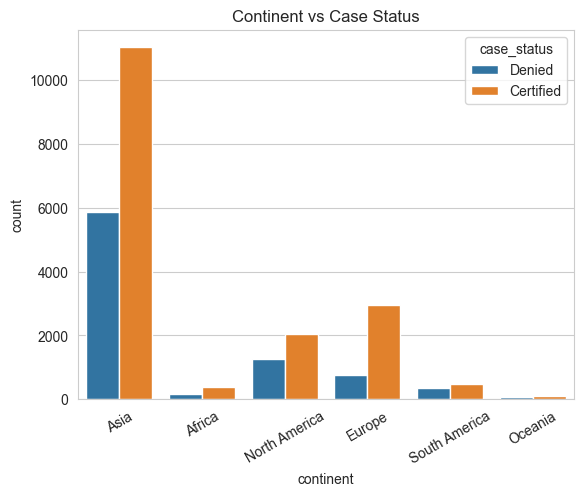

In [185]:
#Continent vs case status
sns.countplot(data=df, x='continent', hue='case_status')
plt.title('Continent vs Case Status')
plt.xticks(rotation=30)
plt.show()

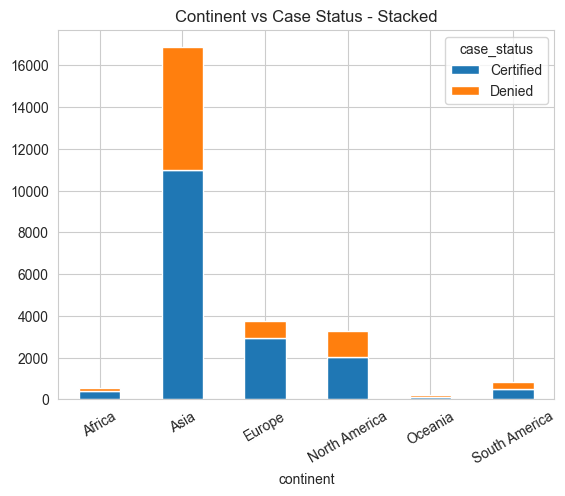

In [186]:
ct = pd.crosstab(df['continent'], df['case_status'])
ct.plot(kind='bar', stacked=True)
plt.title('Continent vs Case Status - Stacked')
plt.xticks(rotation=30)
plt.show()

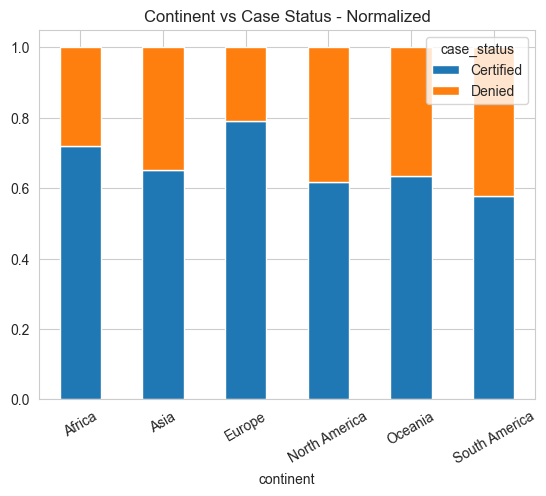

In [187]:
ct_norm = pd.crosstab(df['continent'], df['case_status'], normalize='index')
ct_norm.plot(kind='bar', stacked=True)
plt.title('Continent vs Case Status - Normalized')
plt.xticks(rotation=30)
plt.show()

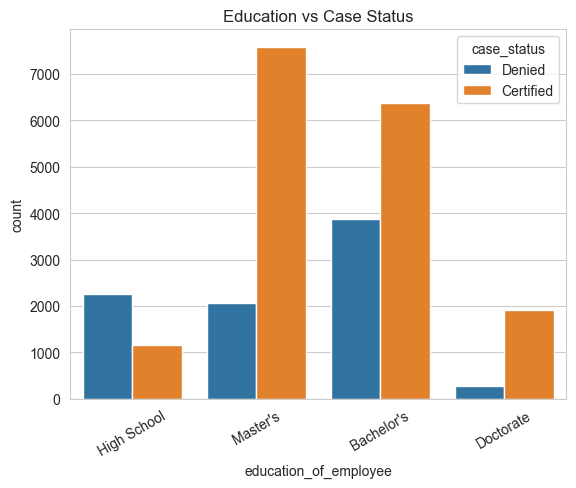

In [188]:
# Education of Employees vs Case status
sns.countplot(data=df, x='education_of_employee', hue='case_status')
plt.title('Education vs Case Status')
plt.xticks(rotation=30)
plt.show()

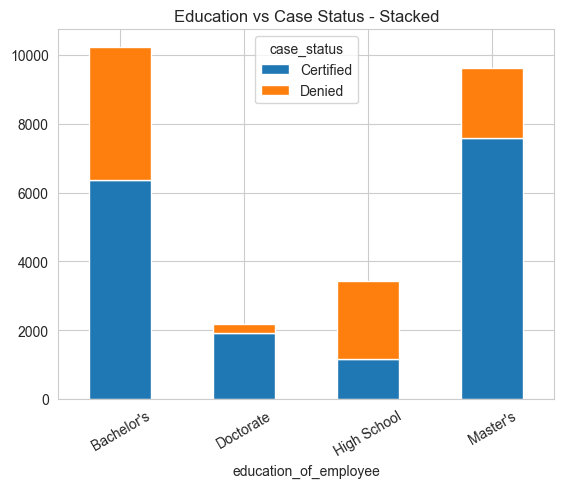

In [189]:
ct = pd.crosstab(df['education_of_employee'], df['case_status'])
ct.plot(kind='bar', stacked=True)
plt.title('Education vs Case Status - Stacked')
plt.xticks(rotation=30)
plt.show()


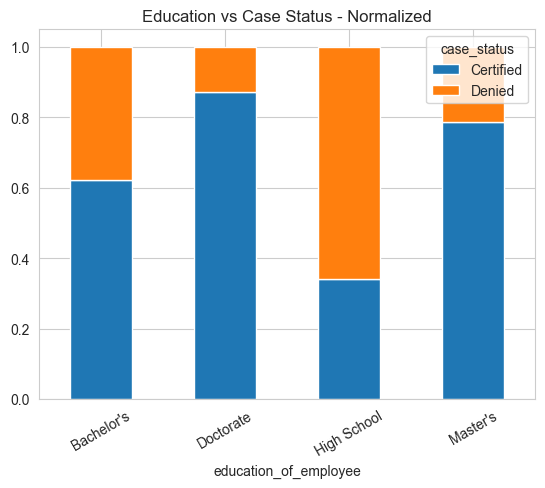

In [190]:
ct_norm = pd.crosstab(df['education_of_employee'], df['case_status'], normalize='index')
ct_norm.plot(kind='bar', stacked=True)
plt.title('Education vs Case Status - Normalized')
plt.xticks(rotation=30)
plt.show()

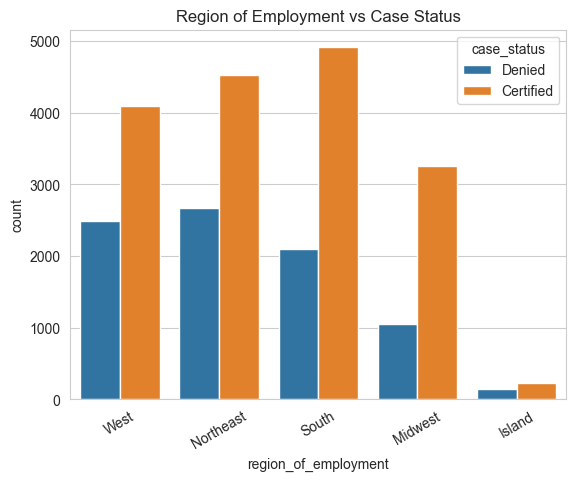

In [192]:
#Region of employees vs case status
sns.countplot(data=df, x='region_of_employment', hue='case_status')
plt.title('Region of Employment vs Case Status')
plt.xticks(rotation=30)
plt.show()

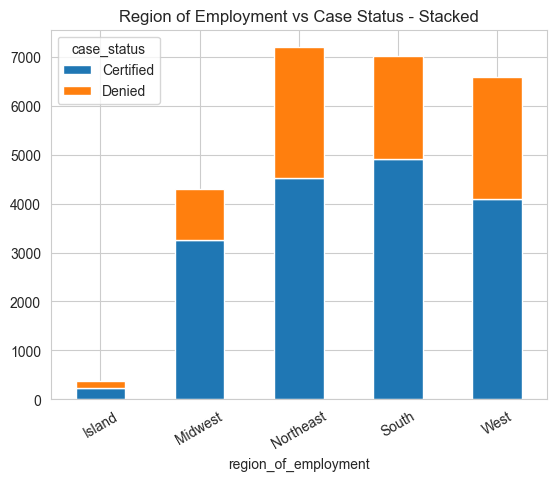

In [193]:
ct = pd.crosstab(df['region_of_employment'], df['case_status'])
ct.plot(kind='bar', stacked=True)
plt.title('Region of Employment vs Case Status - Stacked')
plt.xticks(rotation=30)
plt.show()

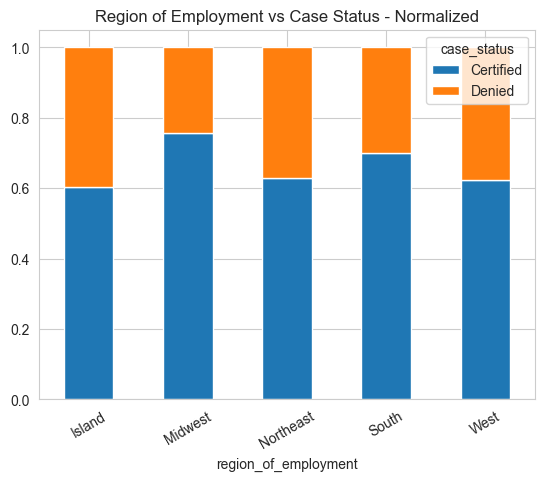

In [194]:
ct_norm = pd.crosstab(df['region_of_employment'], df['case_status'], normalize='index')
ct_norm.plot(kind='bar', stacked=True)
plt.title('Region of Employment vs Case Status - Normalized')
plt.xticks(rotation=30)
plt.show()

In [159]:
df[df['education_of_employee']=='High School']['case_status'].value_counts()


case_status
Denied       2256
Certified    1164
Name: count, dtype: int64

In [150]:
df[df['education_of_employee']=='Doctorate']['case_status'].value_counts()

case_status
Certified    1912
Denied        280
Name: count, dtype: int64

In [157]:
df[df['education_of_employee']=="Master's"]['case_status'].value_counts()

case_status
Certified    7575
Denied       2059
Name: count, dtype: int64

In [155]:
print(df.groupby('education_of_employee')['case_status'].value_counts(normalize=True).unstack())


case_status            Certified    Denied
education_of_employee                     
Bachelor's              0.622142  0.377858
Doctorate               0.872263  0.127737
High School             0.340351  0.659649
Master's                0.786278  0.213722


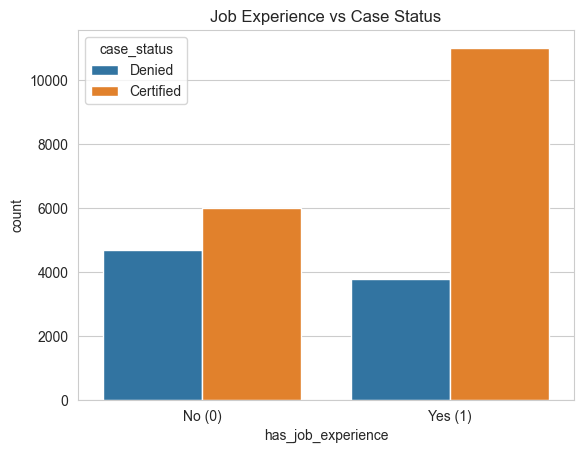

In [197]:
#Has job experience vs Case status
sns.countplot(data=df, x='has_job_experience', hue='case_status')
plt.title('Job Experience vs Case Status')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])
plt.show()

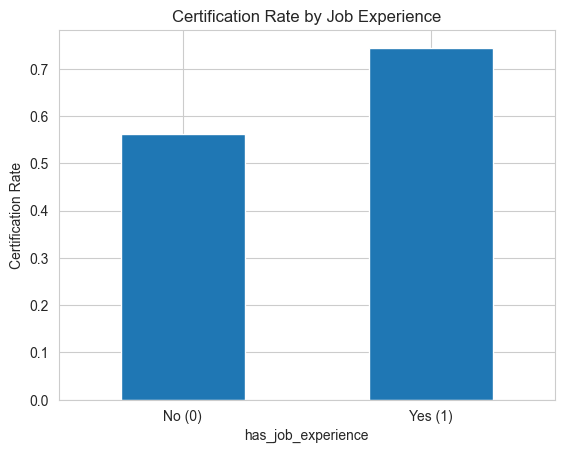

In [198]:
cert_rate = df.groupby('has_job_experience')['case_status'].apply(lambda x: (x == 'Certified').mean())
cert_rate.plot(kind='bar')
plt.title('Certification Rate by Job Experience')
plt.ylabel('Certification Rate')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'], rotation=0)
plt.show()

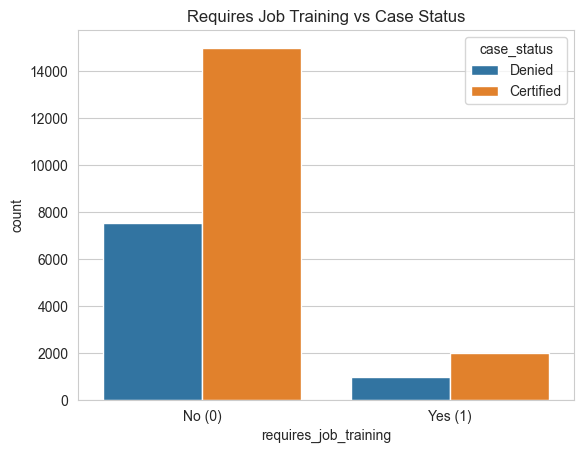

In [200]:
#Requeires Job Training vs case status
sns.countplot(data=df, x='requires_job_training', hue='case_status')
plt.title('Requires Job Training vs Case Status')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])
plt.show()

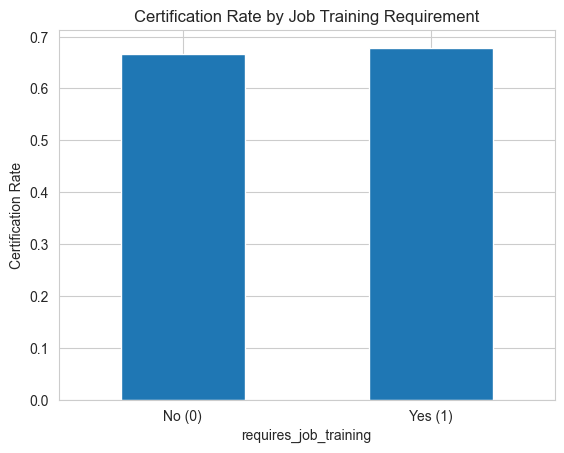

In [201]:
cert_rate = df.groupby('requires_job_training')['case_status'].apply(lambda x: (x == 'Certified').mean())
cert_rate.plot(kind='bar')
plt.title('Certification Rate by Job Training Requirement')
plt.ylabel('Certification Rate')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'], rotation=0)
plt.show()

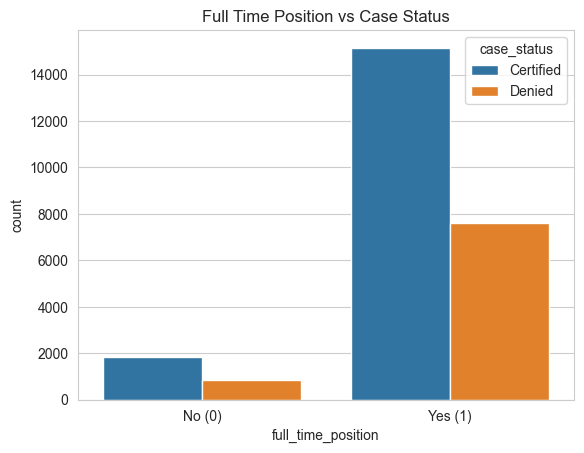

In [202]:
#Full time position vs case status
sns.countplot(data=df, x='full_time_position', hue='case_status')
plt.title('Full Time Position vs Case Status')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])
plt.show()

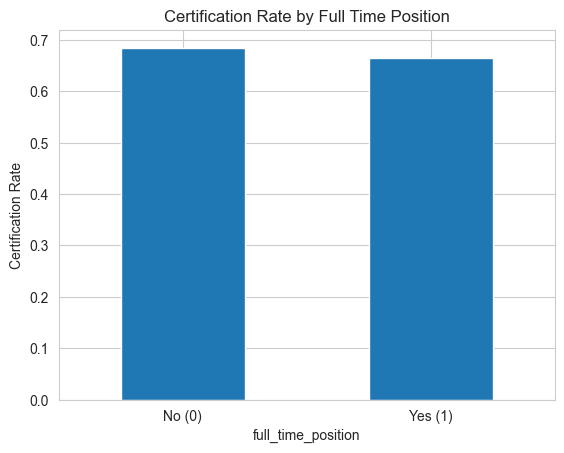

In [203]:
cert_rate = df.groupby('full_time_position')['case_status'].apply(lambda x: (x == 'Certified').mean())
cert_rate.plot(kind='bar')
plt.title('Certification Rate by Full Time Position')
plt.ylabel('Certification Rate')
plt.xticks([0, 1], ['No (0)', 'Yes (1)'], rotation=0)
plt.show()

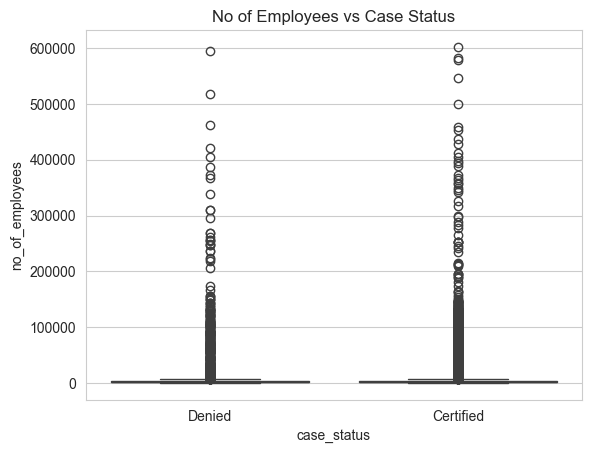

In [204]:
#No of employees vs case status
sns.boxplot(data=df, x='case_status', y='no_of_employees')
plt.title('No of Employees vs Case Status')
plt.show()

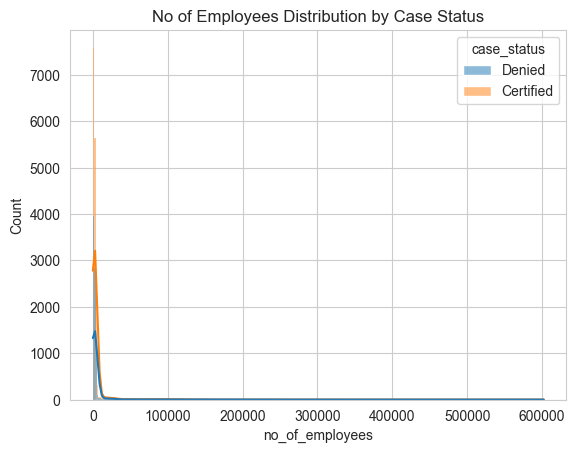

In [205]:
sns.histplot(data=df, x='no_of_employees', hue='case_status', kde=True)
plt.title('No of Employees Distribution by Case Status')
plt.show()

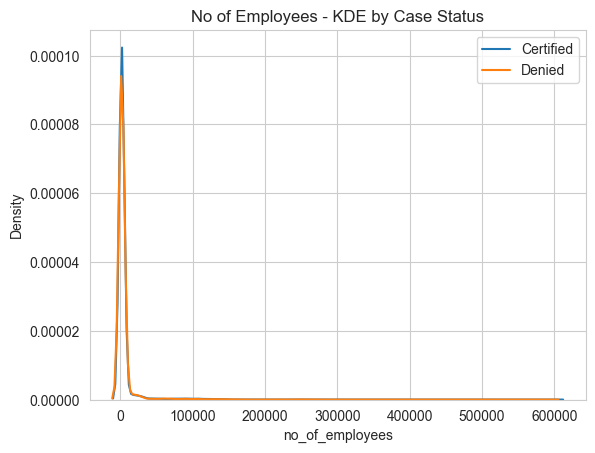

In [206]:
sns.kdeplot(data=df[df['case_status']=='Certified'], x='no_of_employees', label='Certified')
sns.kdeplot(data=df[df['case_status']=='Denied'], x='no_of_employees', label='Denied')
plt.title('No of Employees - KDE by Case Status')
plt.legend()
plt.show()

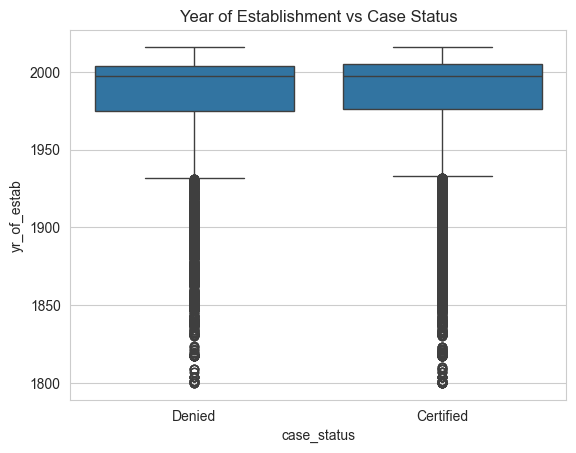

In [207]:
#Yr of estab vs case status
sns.boxplot(data=df, x='case_status', y='yr_of_estab')
plt.title('Year of Establishment vs Case Status')
plt.show()

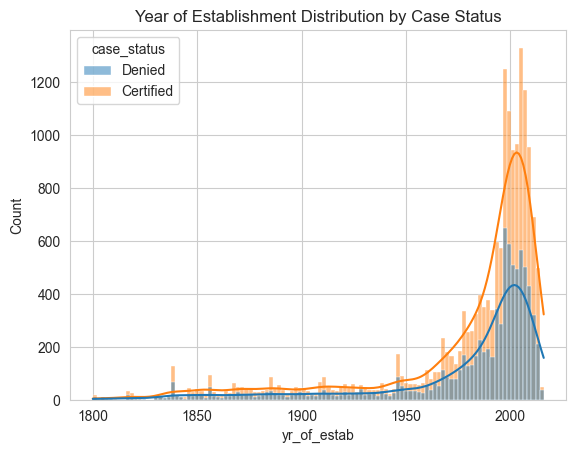

In [208]:
sns.histplot(data=df, x='yr_of_estab', hue='case_status', kde=True)
plt.title('Year of Establishment Distribution by Case Status')
plt.show()

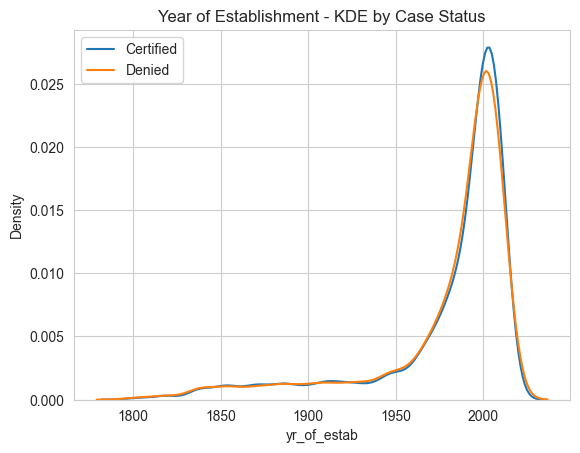

In [209]:
sns.kdeplot(data=df[df['case_status']=='Certified'], x='yr_of_estab', label='Certified')
sns.kdeplot(data=df[df['case_status']=='Denied'], x='yr_of_estab', label='Denied')
plt.title('Year of Establishment - KDE by Case Status')
plt.legend()
plt.show()

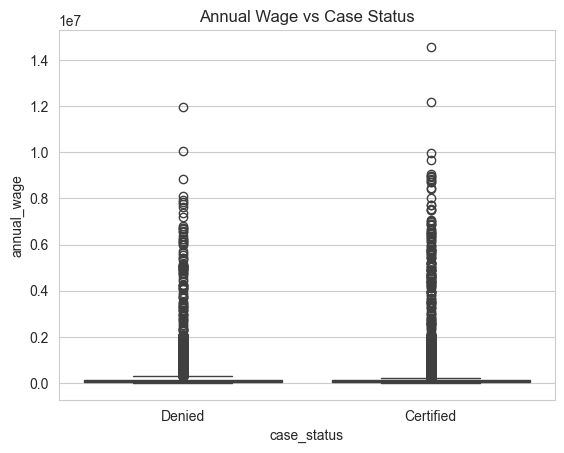

In [210]:
#Anual wage
sns.boxplot(data=df, x='case_status', y='annual_wage')
plt.title('Annual Wage vs Case Status')
plt.show()

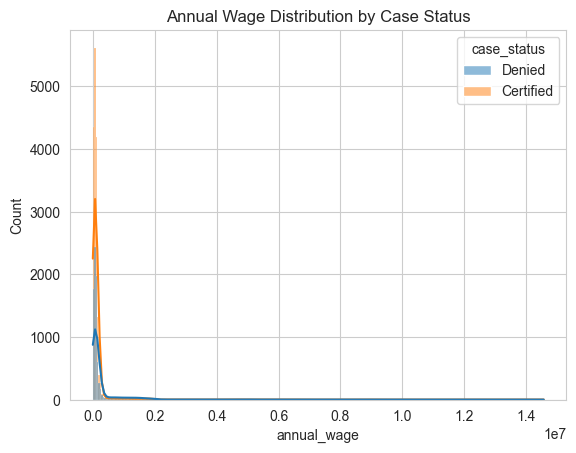

In [211]:
sns.histplot(data=df, x='annual_wage', hue='case_status', kde=True)
plt.title('Annual Wage Distribution by Case Status')
plt.show()

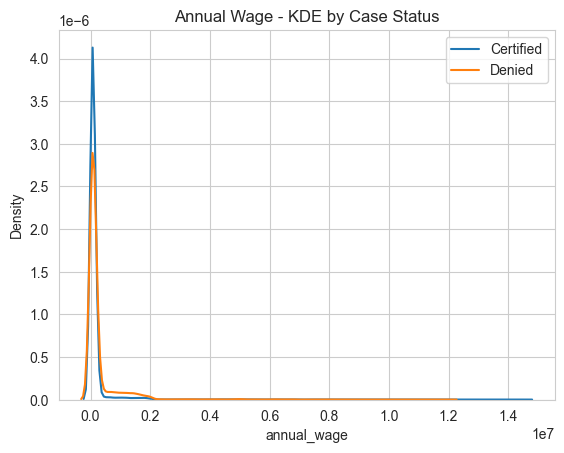

In [212]:
sns.kdeplot(data=df[df['case_status']=='Certified'], x='annual_wage', label='Certified')
sns.kdeplot(data=df[df['case_status']=='Denied'], x='annual_wage', label='Denied')
plt.title('Annual Wage - KDE by Case Status')
plt.legend()
plt.show()

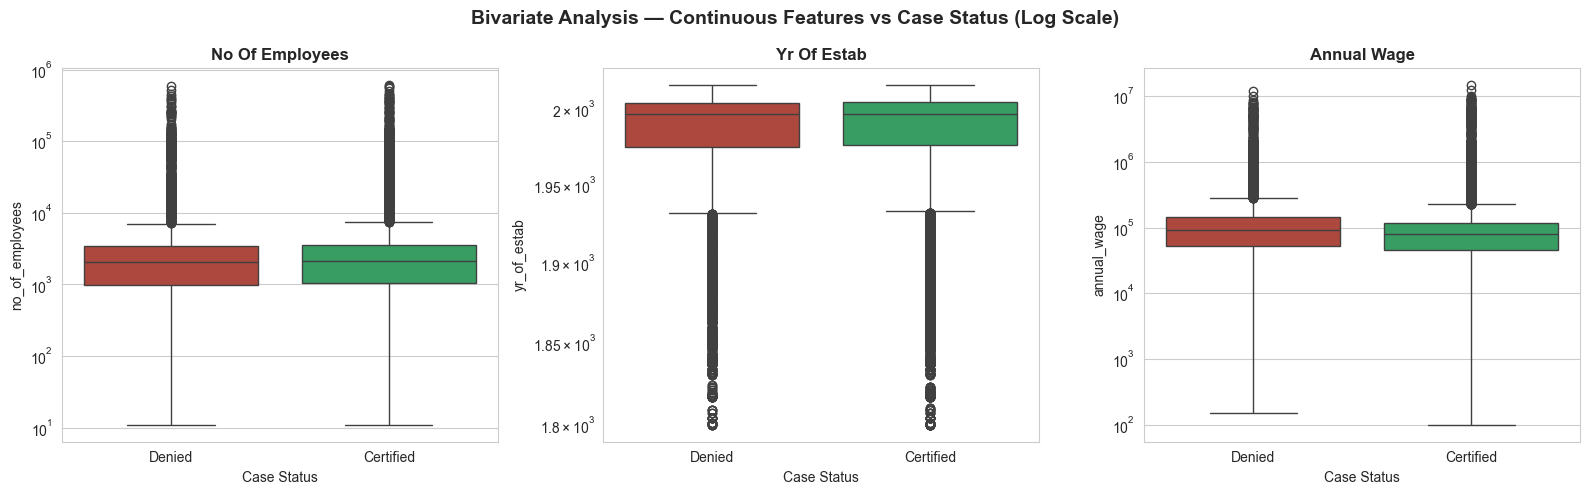

In [142]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['no_of_employees', 'yr_of_estab', 'annual_wage']):
    sns.boxplot(x='case_status', y=col, data=df, ax=axes[i],
                palette={'Certified': '#27ae60', 'Denied': '#c0392b'})
    axes[i].set_yscale('log')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Case Status')

plt.suptitle('Bivariate Analysis — Continuous Features vs Case Status (Log Scale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

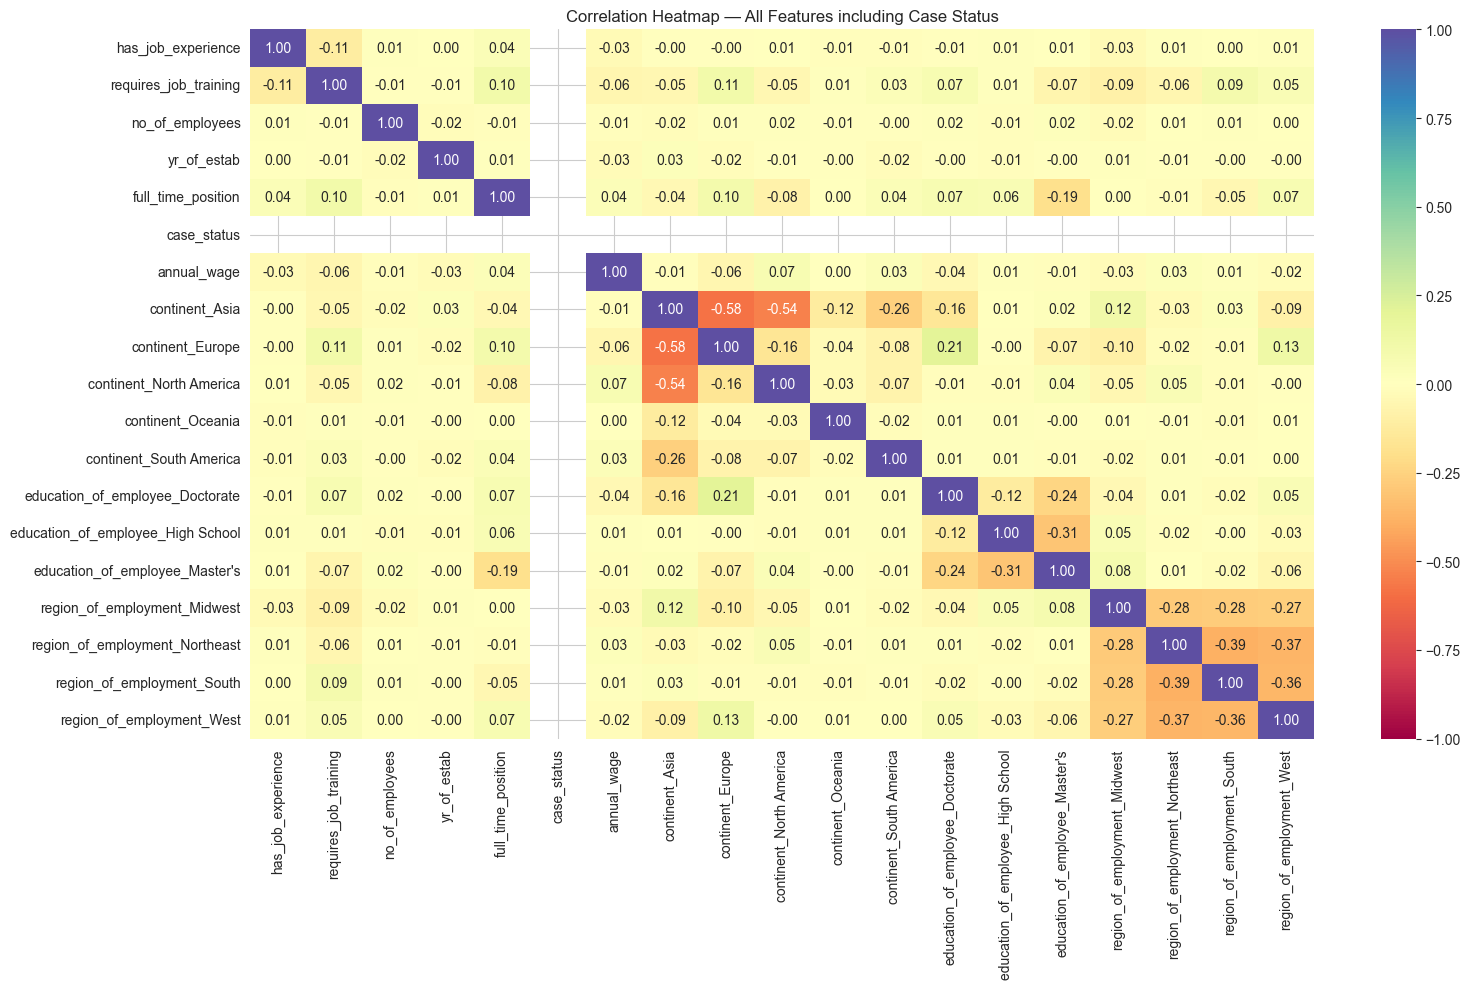

In [277]:
df_temp = df.copy()
df_temp['case_status'] = df_temp['case_status'].map({'Certified': 1, 'Denied': 0})

plt.figure(figsize=(16, 10))
sns.heatmap(df_temp.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.title('Correlation Heatmap — All Features including Case Status')
plt.tight_layout()
plt.show()

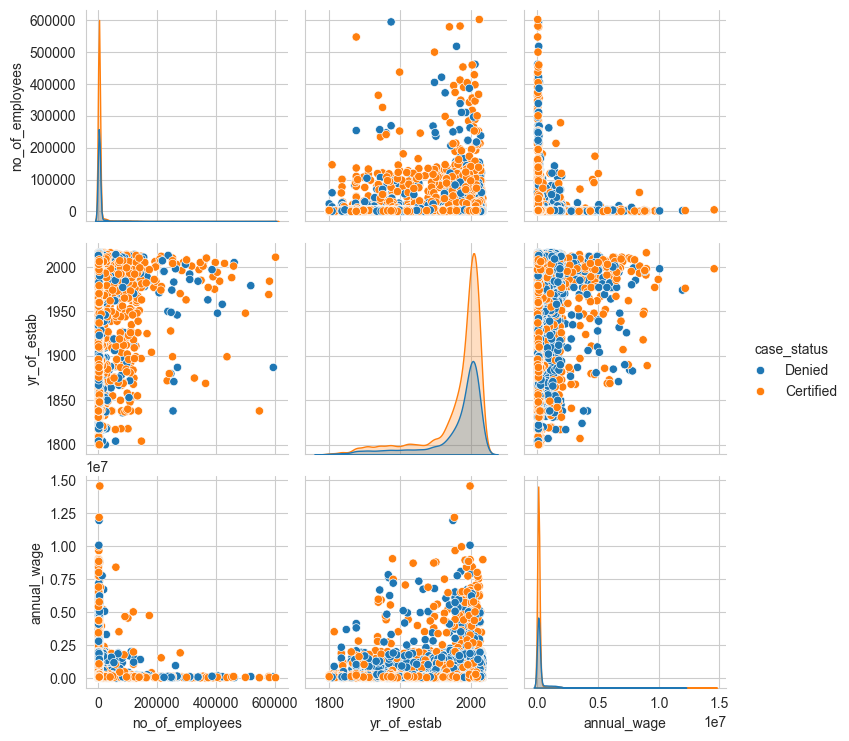

In [214]:
# Pairplot
sns.pairplot(df[['no_of_employees', 'yr_of_estab', 'annual_wage', 'case_status']], hue='case_status')
plt.show()

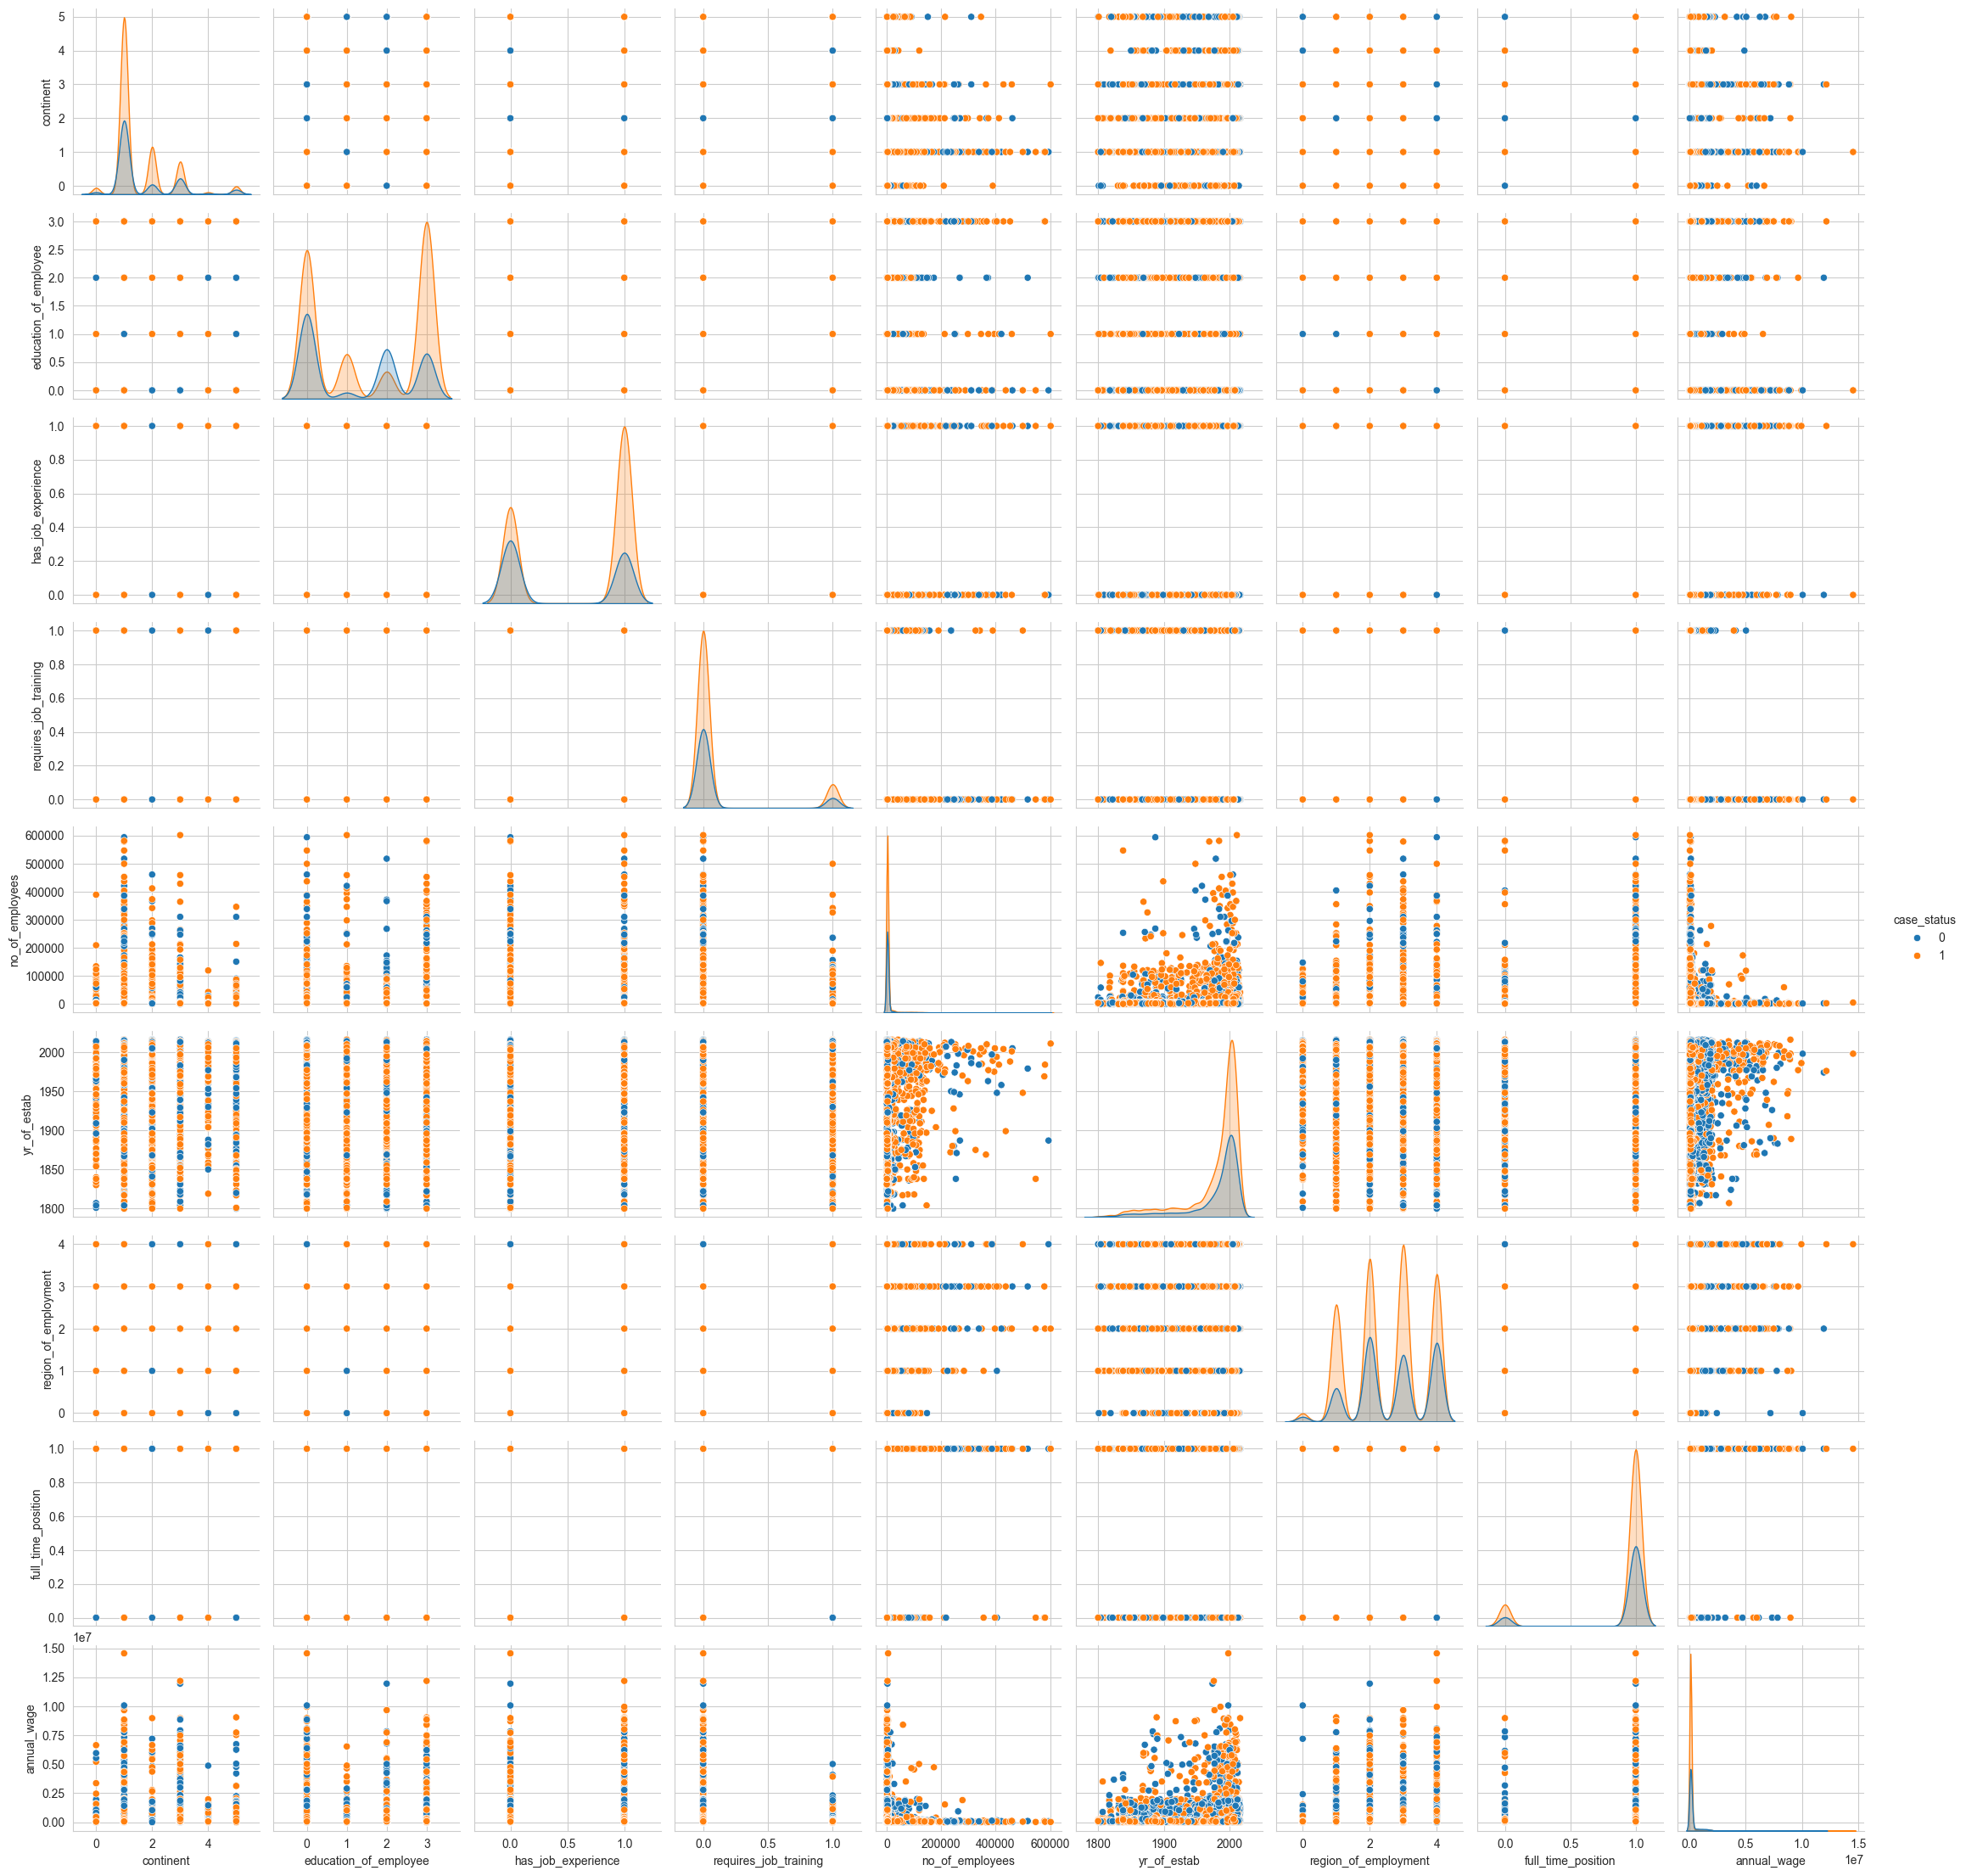

In [215]:
df_temp = df.copy()
df_temp['case_status'] = df_temp['case_status'].map({'Certified': 1, 'Denied': 0})

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = ['continent', 'education_of_employee', 'region_of_employment']
for col in cat_cols:
    df_temp[col] = le.fit_transform(df_temp[col])

df_temp = df_temp.drop(columns=['case_id'])

sns.pairplot(df_temp, hue='case_status')
plt.show()

### Data Prep

In [216]:
# Encode target
df['case_status'] = df['case_status'].map({'Certified': 1, 'Denied': 0})

# One-hot encode
df = pd.get_dummies(df, columns=['continent', 'education_of_employee', 'region_of_employment'], drop_first=True)

# Drop case_id
df = df.drop(columns=['case_id'])

# Split
X = df.drop(columns=['case_status'])
y = df['case_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(20384, 18) (5096, 18)
case_status
1    13614
0     6770
Name: count, dtype: int64


### Decision Tree - base

In [229]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Train
y_train_pred = dt.predict(X_train)
print("TRAIN")
print(classification_report(y_train, y_train_pred))

# Test
y_test_pred = dt.predict(X_test)
print("TEST")
print(classification_report(y_test, y_test_pred))



TRAIN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6770
           1       1.00      1.00      1.00     13614

    accuracy                           1.00     20384
   macro avg       1.00      1.00      1.00     20384
weighted avg       1.00      1.00      1.00     20384

TEST
              precision    recall  f1-score   support

           0       0.48      0.49      0.48      1692
           1       0.74      0.73      0.74      3404

    accuracy                           0.65      5096
   macro avg       0.61      0.61      0.61      5096
weighted avg       0.65      0.65      0.65      5096



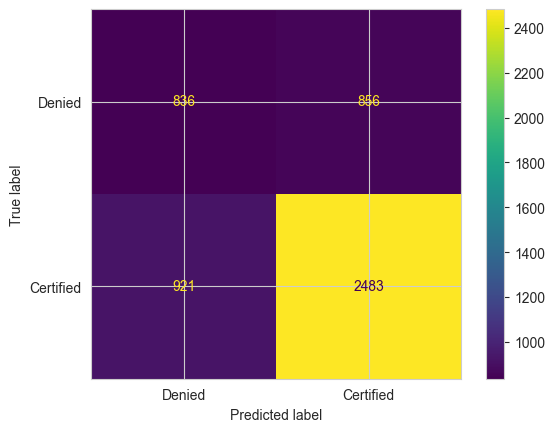

In [230]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Certified'])
disp.plot()
plt.show()

* Decision Tree shows severe overfitting, train accuracy 100% vs test accuracy 65%. The model has memorized training data and fails to generalize.
* Ensemble methods like Bagging and Random Forest should reduce this variance

### Bagging Classifier

In [231]:
bag = BaggingClassifier(random_state=42)
bag.fit(X_train, y_train)

y_train_pred = bag.predict(X_train)
print("TRAIN")
print(classification_report(y_train, y_train_pred))

y_test_pred = bag.predict(X_test)
print("TEST")
print(classification_report(y_test, y_test_pred))

TRAIN
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      6770
           1       0.99      0.98      0.99     13614

    accuracy                           0.98     20384
   macro avg       0.98      0.98      0.98     20384
weighted avg       0.98      0.98      0.98     20384

TEST
              precision    recall  f1-score   support

           0       0.53      0.53      0.53      1692
           1       0.77      0.77      0.77      3404

    accuracy                           0.69      5096
   macro avg       0.65      0.65      0.65      5096
weighted avg       0.69      0.69      0.69      5096



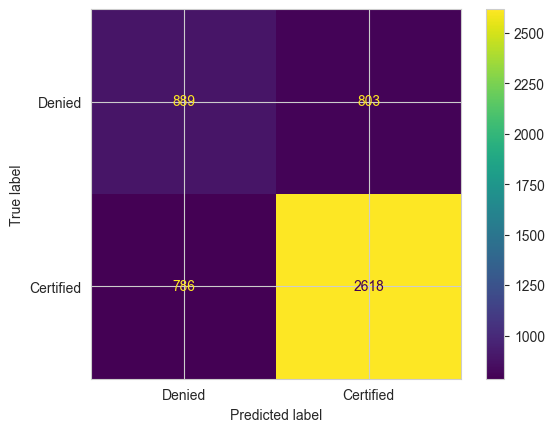

In [232]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Certified'])
disp.plot()
plt.show()

* Bagging improved over Decision Tree on all metrics.
* Overfitting reduced slightly.
* Denied class still weak due to class imbalance.

### Random Forest

In [236]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
print("TRAIN")
print(classification_report(y_train, y_train_pred))

y_test_pred = rf.predict(X_test)
print("TEST")
print(classification_report(y_test, y_test_pred))



TRAIN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6770
           1       1.00      1.00      1.00     13614

    accuracy                           1.00     20384
   macro avg       1.00      1.00      1.00     20384
weighted avg       1.00      1.00      1.00     20384

TEST
              precision    recall  f1-score   support

           0       0.59      0.48      0.53      1692
           1       0.76      0.83      0.80      3404

    accuracy                           0.71      5096
   macro avg       0.67      0.66      0.66      5096
weighted avg       0.70      0.71      0.71      5096



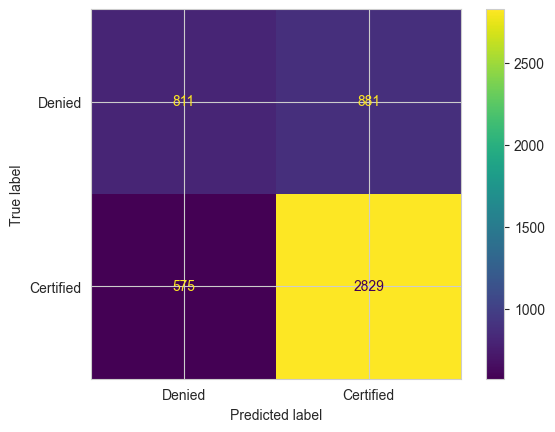

In [237]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Certified'])
disp.plot()
plt.show()

* Random Forest improved overall accuracy to 71%.
* Certified class recall improved to 0.83.
* However Denied class recall dropped model still biased toward majority class.

### ADA Boosting

In [241]:
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)

y_train_pred = ada.predict(X_train)
print("TRAIN")
print(classification_report(y_train, y_train_pred))

y_test_pred = ada.predict(X_test)
print("TEST")
print(classification_report(y_test, y_test_pred))


TRAIN
              precision    recall  f1-score   support

           0       0.65      0.44      0.52      6770
           1       0.76      0.88      0.82     13614

    accuracy                           0.74     20384
   macro avg       0.71      0.66      0.67     20384
weighted avg       0.72      0.74      0.72     20384

TEST
              precision    recall  f1-score   support

           0       0.63      0.42      0.50      1692
           1       0.75      0.88      0.81      3404

    accuracy                           0.72      5096
   macro avg       0.69      0.65      0.66      5096
weighted avg       0.71      0.72      0.71      5096



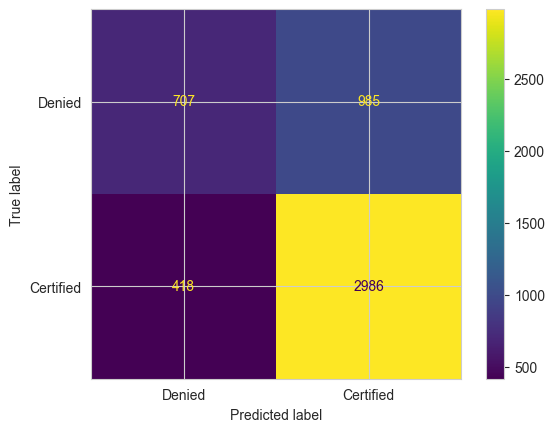

In [242]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Certified'])
disp.plot()
plt.show()

* AdaBoost shows almost no overfitting train and test scores are very close.
* Overall accuracy improved to 72% but Denied recall dropped to 0.42 model is predicting Certified more aggressively.

### Gradiant Boosting

In [244]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_train_pred = gb.predict(X_train)
print("TRAIN")
print(classification_report(y_train, y_train_pred))

y_test_pred = gb.predict(X_test)
print("TEST")
print(classification_report(y_test, y_test_pred))

TRAIN
              precision    recall  f1-score   support

           0       0.67      0.50      0.57      6770
           1       0.78      0.88      0.82     13614

    accuracy                           0.75     20384
   macro avg       0.72      0.69      0.70     20384
weighted avg       0.74      0.75      0.74     20384

TEST
              precision    recall  f1-score   support

           0       0.64      0.46      0.54      1692
           1       0.77      0.87      0.81      3404

    accuracy                           0.73      5096
   macro avg       0.70      0.67      0.68      5096
weighted avg       0.72      0.73      0.72      5096



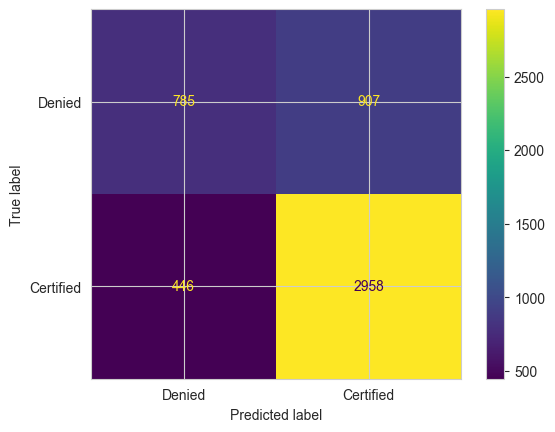

In [245]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Certified'])
disp.plot()
plt.show()

### XGBoost

In [247]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_train_pred = xgb.predict(X_train)
print("TRAIN")
print(classification_report(y_train, y_train_pred))

y_test_pred = xgb.predict(X_test)
print("TEST")
print(classification_report(y_test, y_test_pred))

TRAIN
              precision    recall  f1-score   support

           0       0.81      0.65      0.72      6770
           1       0.84      0.93      0.88     13614

    accuracy                           0.83     20384
   macro avg       0.83      0.79      0.80     20384
weighted avg       0.83      0.83      0.83     20384

TEST
              precision    recall  f1-score   support

           0       0.61      0.45      0.52      1692
           1       0.76      0.85      0.80      3404

    accuracy                           0.72      5096
   macro avg       0.68      0.65      0.66      5096
weighted avg       0.71      0.72      0.71      5096



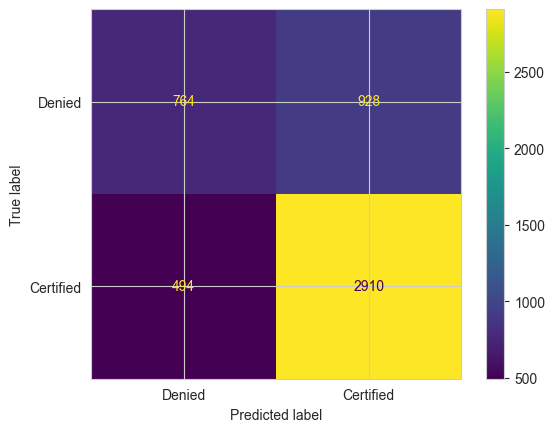

In [248]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Certified'])
disp.plot()
plt.show()

* XGBoost shows slight overfitting. Denied recall at 0.45 is weak.
* Gradient Boosting is best overall on original data.
* All models struggle with Denied class due to class imbalance SMOTE and undersampling should improve this significantly.

### SMOTE


In [250]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE: {1: 13614, 0: 6770}
After SMOTE: {1: 13614, 0: 13614}



Decision Tree — TRAIN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13614
           1       1.00      1.00      1.00     13614

    accuracy                           1.00     27228
   macro avg       1.00      1.00      1.00     27228
weighted avg       1.00      1.00      1.00     27228

Decision Tree — TEST
              precision    recall  f1-score   support

           0       0.47      0.51      0.49      1692
           1       0.75      0.71      0.73      3404

    accuracy                           0.65      5096
   macro avg       0.61      0.61      0.61      5096
weighted avg       0.65      0.65      0.65      5096



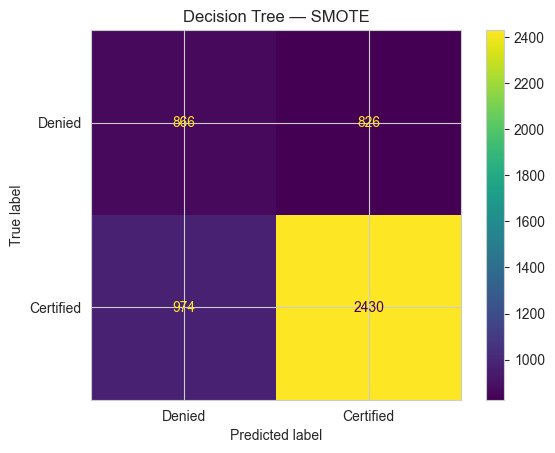


Bagging — TRAIN
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     13614
           1       0.99      0.98      0.99     13614

    accuracy                           0.99     27228
   macro avg       0.99      0.99      0.99     27228
weighted avg       0.99      0.99      0.99     27228

Bagging — TEST
              precision    recall  f1-score   support

           0       0.51      0.54      0.53      1692
           1       0.77      0.74      0.76      3404

    accuracy                           0.68      5096
   macro avg       0.64      0.64      0.64      5096
weighted avg       0.68      0.68      0.68      5096



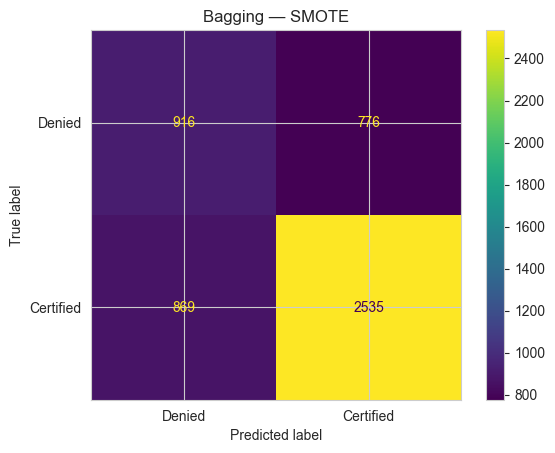


Random Forest — TRAIN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13614
           1       1.00      1.00      1.00     13614

    accuracy                           1.00     27228
   macro avg       1.00      1.00      1.00     27228
weighted avg       1.00      1.00      1.00     27228

Random Forest — TEST
              precision    recall  f1-score   support

           0       0.58      0.52      0.54      1692
           1       0.77      0.81      0.79      3404

    accuracy                           0.71      5096
   macro avg       0.67      0.66      0.67      5096
weighted avg       0.71      0.71      0.71      5096



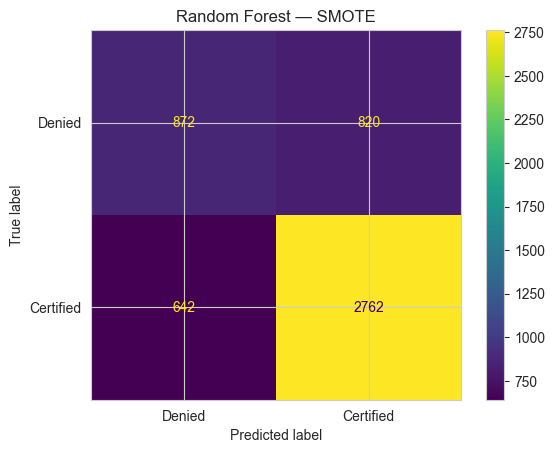


AdaBoost — TRAIN
              precision    recall  f1-score   support

           0       0.78      0.77      0.78     13614
           1       0.77      0.79      0.78     13614

    accuracy                           0.78     27228
   macro avg       0.78      0.78      0.78     27228
weighted avg       0.78      0.78      0.78     27228

AdaBoost — TEST
              precision    recall  f1-score   support

           0       0.57      0.55      0.56      1692
           1       0.78      0.79      0.78      3404

    accuracy                           0.71      5096
   macro avg       0.67      0.67      0.67      5096
weighted avg       0.71      0.71      0.71      5096



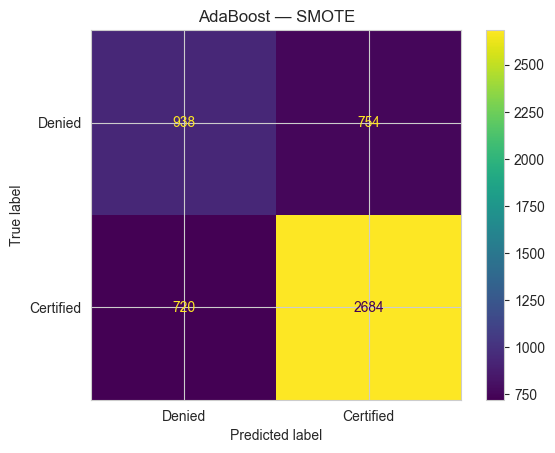


Gradient Boosting — TRAIN
              precision    recall  f1-score   support

           0       0.83      0.76      0.79     13614
           1       0.78      0.84      0.81     13614

    accuracy                           0.80     27228
   macro avg       0.80      0.80      0.80     27228
weighted avg       0.80      0.80      0.80     27228

Gradient Boosting — TEST
              precision    recall  f1-score   support

           0       0.61      0.51      0.56      1692
           1       0.78      0.84      0.81      3404

    accuracy                           0.73      5096
   macro avg       0.70      0.68      0.68      5096
weighted avg       0.72      0.73      0.72      5096



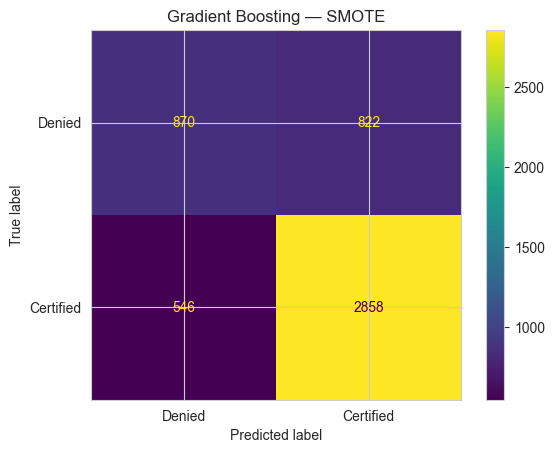


XGBoost — TRAIN
              precision    recall  f1-score   support

           0       0.89      0.82      0.85     13614
           1       0.83      0.90      0.86     13614

    accuracy                           0.86     27228
   macro avg       0.86      0.86      0.86     27228
weighted avg       0.86      0.86      0.86     27228

XGBoost — TEST
              precision    recall  f1-score   support

           0       0.61      0.49      0.54      1692
           1       0.77      0.85      0.81      3404

    accuracy                           0.73      5096
   macro avg       0.69      0.67      0.67      5096
weighted avg       0.72      0.73      0.72      5096



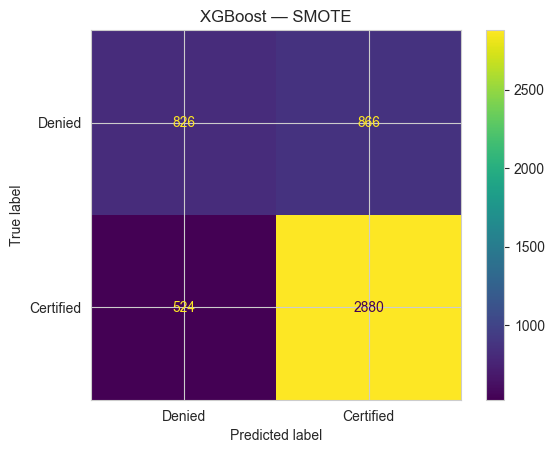

In [251]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Bagging': BaggingClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)

    y_train_pred = model.predict(X_train_smote)
    print(f"\n{name} — TRAIN")
    print(classification_report(y_train_smote, y_train_pred))

    y_test_pred = model.predict(X_test)
    print(f"{name} — TEST")
    print(classification_report(y_test, y_test_pred))

    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Certified'])
    disp.plot()
    plt.title(f'{name} — SMOTE')
    plt.show()

* SMOTE improved Denied recall across all models.
* AdaBoost showed biggest improvement in Denied recall from 0.42 to 0.55.
* Gradient Boosting and XGBoost still best overall at 73% accuracy.

### Umdersampled

In [254]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Before Undersampling:", y_train.value_counts().to_dict())
print("After Undersampling:", pd.Series(y_train_under).value_counts().to_dict())

Before Undersampling: {1: 13614, 0: 6770}
After Undersampling: {0: 6770, 1: 6770}



Decision Tree — TRAIN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6770
           1       1.00      1.00      1.00      6770

    accuracy                           1.00     13540
   macro avg       1.00      1.00      1.00     13540
weighted avg       1.00      1.00      1.00     13540

Decision Tree — TEST
              precision    recall  f1-score   support

           0       0.45      0.63      0.52      1692
           1       0.77      0.61      0.68      3404

    accuracy                           0.62      5096
   macro avg       0.61      0.62      0.60      5096
weighted avg       0.66      0.62      0.63      5096



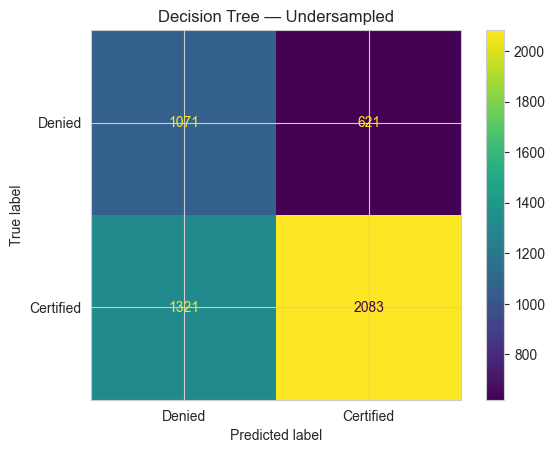


Bagging — TRAIN
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      6770
           1       0.99      0.97      0.98      6770

    accuracy                           0.98     13540
   macro avg       0.98      0.98      0.98     13540
weighted avg       0.98      0.98      0.98     13540

Bagging — TEST
              precision    recall  f1-score   support

           0       0.47      0.73      0.57      1692
           1       0.81      0.60      0.69      3404

    accuracy                           0.64      5096
   macro avg       0.64      0.66      0.63      5096
weighted avg       0.70      0.64      0.65      5096



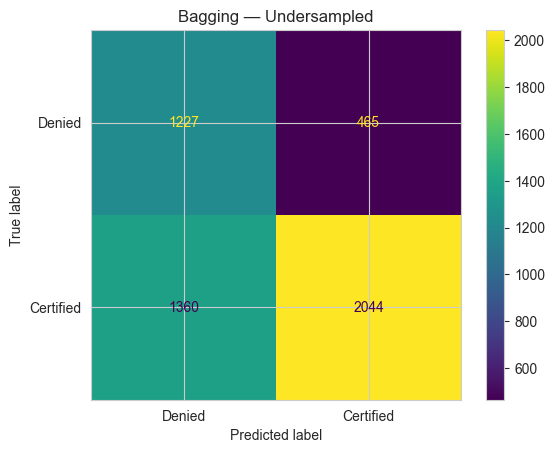


Random Forest — TRAIN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6770
           1       1.00      1.00      1.00      6770

    accuracy                           1.00     13540
   macro avg       1.00      1.00      1.00     13540
weighted avg       1.00      1.00      1.00     13540

Random Forest — TEST
              precision    recall  f1-score   support

           0       0.50      0.69      0.58      1692
           1       0.81      0.66      0.73      3404

    accuracy                           0.67      5096
   macro avg       0.66      0.68      0.66      5096
weighted avg       0.71      0.67      0.68      5096



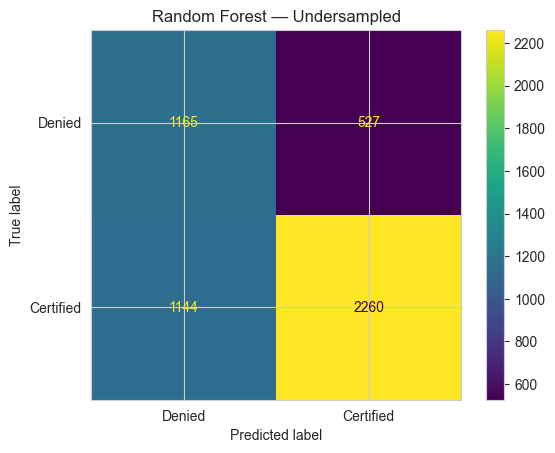


AdaBoost — TRAIN
              precision    recall  f1-score   support

           0       0.71      0.66      0.69      6770
           1       0.68      0.73      0.71      6770

    accuracy                           0.70     13540
   macro avg       0.70      0.70      0.70     13540
weighted avg       0.70      0.70      0.70     13540

AdaBoost — TEST
              precision    recall  f1-score   support

           0       0.53      0.63      0.58      1692
           1       0.80      0.72      0.76      3404

    accuracy                           0.69      5096
   macro avg       0.66      0.68      0.67      5096
weighted avg       0.71      0.69      0.70      5096



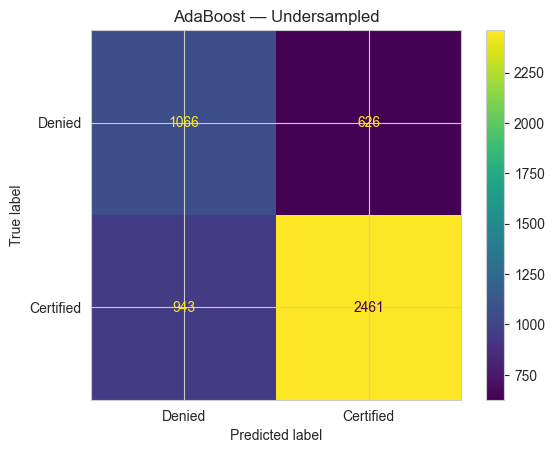


Gradient Boosting — TRAIN
              precision    recall  f1-score   support

           0       0.72      0.71      0.72      6770
           1       0.71      0.73      0.72      6770

    accuracy                           0.72     13540
   macro avg       0.72      0.72      0.72     13540
weighted avg       0.72      0.72      0.72     13540

Gradient Boosting — TEST
              precision    recall  f1-score   support

           0       0.53      0.67      0.59      1692
           1       0.81      0.71      0.75      3404

    accuracy                           0.69      5096
   macro avg       0.67      0.69      0.67      5096
weighted avg       0.72      0.69      0.70      5096



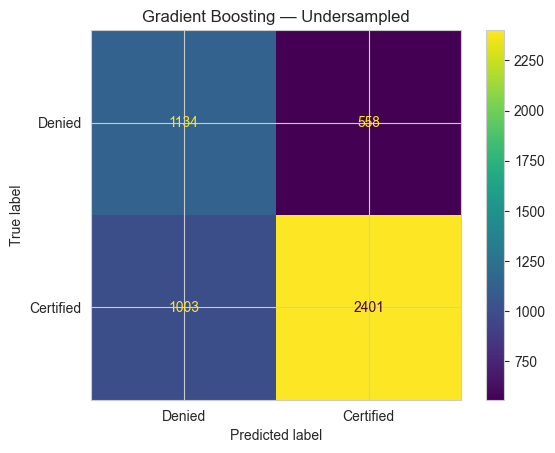


XGBoost — TRAIN
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      6770
           1       0.85      0.84      0.84      6770

    accuracy                           0.84     13540
   macro avg       0.84      0.84      0.84     13540
weighted avg       0.84      0.84      0.84     13540

XGBoost — TEST
              precision    recall  f1-score   support

           0       0.51      0.69      0.59      1692
           1       0.81      0.68      0.74      3404

    accuracy                           0.68      5096
   macro avg       0.66      0.68      0.66      5096
weighted avg       0.71      0.68      0.69      5096



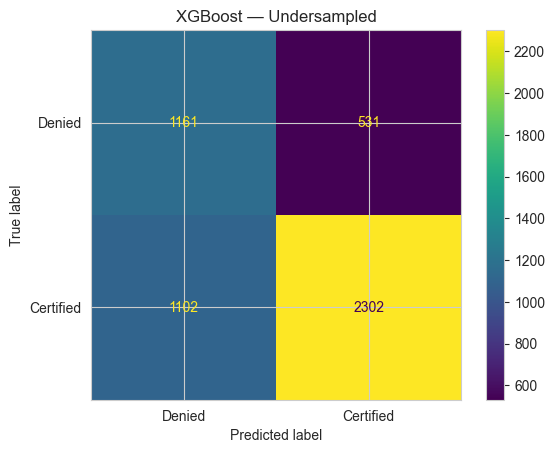

In [255]:
for name, model in models.items():
    model.fit(X_train_under, y_train_under)

    y_train_pred = model.predict(X_train_under)
    print(f"\n{name} — TRAIN")
    print(classification_report(y_train_under, y_train_pred))

    y_test_pred = model.predict(X_test)
    print(f"{name} — TEST")
    print(classification_report(y_test, y_test_pred))

    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Certified'])
    disp.plot()
    plt.title(f'{name} — Undersampled')
    plt.show()

### Hyperparameter Tuning

In [257]:
# 1. Bagging
bag_params = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0]
}

bag_search = RandomizedSearchCV(
    BaggingClassifier(random_state=42),
    bag_params,
    n_iter=10,
    scoring='recall',
    cv=5,
    random_state=42,
    n_jobs=-1
)
bag_search.fit(X_train_under, y_train_under)
print("Best Bagging params:", bag_search.best_params_)

y_test_pred = bag_search.predict(X_test)
print(classification_report(y_test, y_test_pred))

Best Bagging params: {'n_estimators': 200, 'max_samples': 0.5, 'max_features': 0.7}
              precision    recall  f1-score   support

           0       0.51      0.68      0.58      1692
           1       0.81      0.68      0.74      3404

    accuracy                           0.68      5096
   macro avg       0.66      0.68      0.66      5096
weighted avg       0.71      0.68      0.69      5096



In [258]:
# 2. Random Forest
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=10,
    scoring='recall',
    cv=5,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train_under, y_train_under)
print("Best RF params:", rf_search.best_params_)

y_test_pred = rf_search.predict(X_test)
print(classification_report(y_test, y_test_pred))

Best RF params: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5}
              precision    recall  f1-score   support

           0       0.55      0.64      0.59      1692
           1       0.81      0.73      0.77      3404

    accuracy                           0.70      5096
   macro avg       0.68      0.69      0.68      5096
weighted avg       0.72      0.70      0.71      5096



In [259]:
# 3.XGBoost
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.5, 0.7, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    xgb_params,
    n_iter=10,
    scoring='recall',
    cv=5,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train_under, y_train_under)
print("Best XGBoost params:", xgb_search.best_params_)

y_test_pred = xgb_search.predict(X_test)
print(classification_report(y_test, y_test_pred))

Best XGBoost params: {'subsample': 0.5, 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.5}
              precision    recall  f1-score   support

           0       0.55      0.64      0.59      1692
           1       0.80      0.74      0.77      3404

    accuracy                           0.71      5096
   macro avg       0.68      0.69      0.68      5096
weighted avg       0.72      0.71      0.71      5096



* Tuning didn't improve Denied recall significantly.
* Bagging on undersampled data remains best with 0.73 Denied recall.
* This will be our final model.

### Feature importance

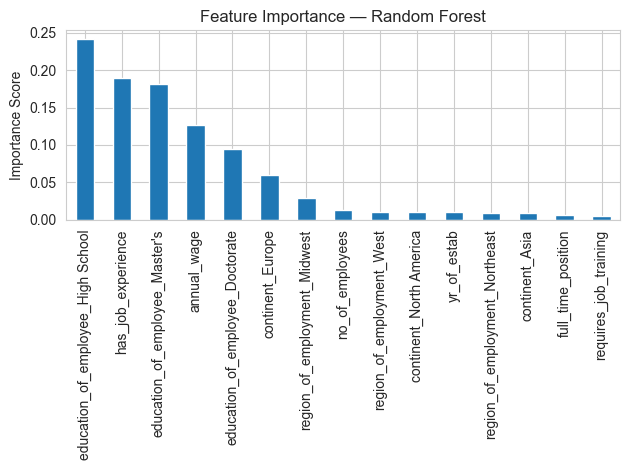

In [262]:
# Feature importance from tuned Random Forest
importances = pd.Series(rf_search.best_estimator_.feature_importances_, index=X.columns)
top15 = importances.nlargest(15)

top15.plot(kind='bar')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

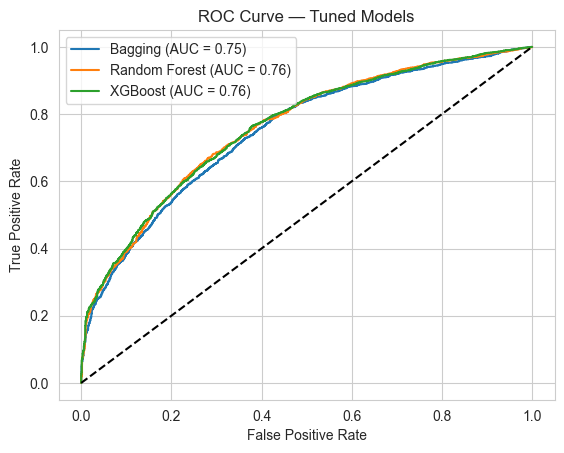

In [266]:
models_tuned = {
    'Bagging': bag_search.best_estimator_,
    'Random Forest': rf_search.best_estimator_,
    'XGBoost': xgb_search.best_estimator_
}

for name, model in models_tuned.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Tuned Models')
plt.legend()
plt.show()

* Bagging on undersampled data selected as final model highest Denied recall of 0.73, which is our business priority.
* Catching Denied cases correctly is more important than overall accuracy.

In [267]:
results = {
    'Model': [
        'Decision Tree', 'Bagging', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost',
        'Decision Tree SMOTE', 'Bagging SMOTE', 'Random Forest SMOTE', 'AdaBoost SMOTE', 'Gradient Boosting SMOTE', 'XGBoost SMOTE',
        'Decision Tree Under', 'Bagging Under', 'Random Forest Under', 'AdaBoost Under', 'Gradient Boosting Under', 'XGBoost Under',
        'Bagging Tuned', 'Random Forest Tuned', 'XGBoost Tuned'
    ],
    'Accuracy': [0.65, 0.69, 0.71, 0.72, 0.73, 0.72,
                 0.65, 0.68, 0.71, 0.71, 0.73, 0.73,
                 0.62, 0.64, 0.67, 0.69, 0.69, 0.68,
                 0.68, 0.70, 0.71],
    'Denied Recall': [0.49, 0.53, 0.48, 0.42, 0.46, 0.45,
                      0.51, 0.54, 0.52, 0.55, 0.51, 0.49,
                      0.63, 0.73, 0.69, 0.63, 0.67, 0.69,
                      0.68, 0.64, 0.64],
    'F1 Denied': [0.48, 0.53, 0.53, 0.50, 0.54, 0.52,
                  0.49, 0.53, 0.54, 0.56, 0.56, 0.54,
                  0.52, 0.57, 0.58, 0.58, 0.59, 0.59,
                  0.58, 0.59, 0.59]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Denied Recall', ascending=False)
print(results_df.to_string(index=False))

                  Model  Accuracy  Denied Recall  F1 Denied
          Bagging Under      0.64           0.73       0.57
    Random Forest Under      0.67           0.69       0.58
          XGBoost Under      0.68           0.69       0.59
          Bagging Tuned      0.68           0.68       0.58
Gradient Boosting Under      0.69           0.67       0.59
          XGBoost Tuned      0.71           0.64       0.59
    Random Forest Tuned      0.70           0.64       0.59
         AdaBoost Under      0.69           0.63       0.58
    Decision Tree Under      0.62           0.63       0.52
         AdaBoost SMOTE      0.71           0.55       0.56
          Bagging SMOTE      0.68           0.54       0.53
                Bagging      0.69           0.53       0.53
    Random Forest SMOTE      0.71           0.52       0.54
    Decision Tree SMOTE      0.65           0.51       0.49
Gradient Boosting SMOTE      0.73           0.51       0.56
          XGBoost SMOTE      0.73       

              precision    recall  f1-score   support

           0       0.47      0.73      0.57      1692
           1       0.81      0.60      0.69      3404

    accuracy                           0.64      5096
   macro avg       0.64      0.66      0.63      5096
weighted avg       0.70      0.64      0.65      5096



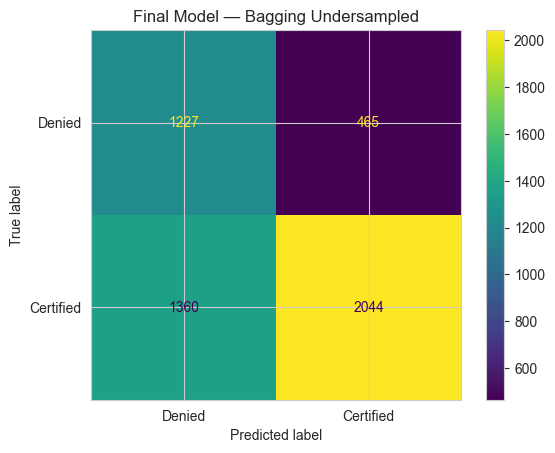

In [280]:
bag_final = BaggingClassifier(random_state=42)
bag_final.fit(X_train_under, y_train_under)

y_test_pred = bag_final.predict(X_test)

print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Certified'])
disp.plot()
plt.title('Final Model — Bagging Undersampled')
plt.show()

* Top 3 by Denied Recall are all Undersampled models
* Bagging Undersampled is clear winner at 0.73 Denied Recall
* Original data models sit at bottom - imbalance hurt them badly
* SMOTE models are in middle - better than original but worse than undersampling
* Tuning didn't help much - untuned undersampled models performed better
* Gradient Boosting and XGBoost had best accuracy on original data but worst Denied Recall
*Undersampling consistently beats SMOTE for Denied Recall across all models